In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import shap
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 使用ASCII减号，兼容性更好

print("✓ 所有库导入完成（包括SHAP）")

✓ 所有库导入完成（包括SHAP）


d:\Anaconda\envs\LSTM\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 第一步：数据加载与时间戳解析

In [3]:
# 读取数据
try:
    df = pd.read_excel('CO2_capacity.xlsx', engine='openpyxl')
    print(f"✓ 成功读取数据，形状：{df.shape}")
except Exception as e:
    raise RuntimeError(f"读取失败：{e}")

# 显示前几行
print(f"\n数据前 5 行：")
print(df.head())

# 确定列
time_col = df.columns[0]  # 第一列是时间戳
target_col = df.columns[-1]  # 最后一列是目标（CO2 容量）

print(f"\n列角色定义：")
print(f"  • 时间列：{time_col}")
print(f"  • 目标列：{target_col}")
print(f"  • 数据频率：1 分钟")
print(f"  • 总记录数：{len(df)}")

✓ 成功读取数据，形状：(7200, 59)

数据前 5 行：
                 Date      PI-2       TI-2         FI-2      PI-3       TI-3  \
0 2020-01-20 00:00:00 -0.053126  34.736652  1543.938721  0.052434  45.023132   
1 2020-01-20 00:01:00 -0.053289  34.732132  1541.767578  0.052564  45.045799   
2 2020-01-20 00:02:00 -0.053386  34.761639  1545.614746  0.052390  45.088932   
3 2020-01-20 00:03:00 -0.053370  34.731682  1544.225952  0.052236  45.071358   
4 2020-01-20 00:04:00 -0.053144  34.718353  1540.848267  0.052370  45.036755   

       O2-3      TI-32      TI-33      TI-34  ...        FI-16      TI-16  \
0  5.170577  37.777477  50.215652  61.217957  ...  9634.049805  34.619560   
1  5.139907  37.836792  50.203251  61.241829  ...  9661.376953  34.598999   
2  5.078373  37.840168  50.180534  61.217957  ...  9662.280273  34.551292   
3  4.915955  37.849812  50.215652  61.322845  ...  9656.855469  34.583843   
4  5.042109  37.914433  50.229359  61.233147  ...  9641.303711  34.584705   

         FI-151     TI-

## 第二步：选择特征并时间顺序分割

In [4]:
# 选定的 12 个特征（来自相关性分析）
 #selected_features = ['TI-34', 'TI-33', 'FI-38', 'TI-19', 'TI-12', 'TI-22', 'TI-24', 'TI-4',' TI-35',' FI-30']

selected_features = ['TI-34', 'TI-33',  'FI-30', 'FI-38', 'TI-4', 'TI-19', 'TI-12', 'TI-22', 'TI-24','TI-28', 'Level Reboiler']

# 验证特征是否存在
missing_features = [f for f in selected_features if f not in df.columns]
if missing_features:
    print(f"⚠ 警告：以下特征不存在：{missing_features}")
    print(f"实际列名：{list(df.columns)}")
    selected_features = [f for f in selected_features if f in df.columns]
    print(f"使用实际存在的特征：{selected_features}")

print(f"\n使用的特征（共 {len(selected_features)} 个）：")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# 提取特征和目标
X = df[selected_features].copy()
y = df[target_col].copy()

# 处理缺失值（用中位数填充）
X.fillna(X.median(), inplace=True)
y.fillna(y.median(), inplace=True)

print(f"\n目标变量统计：")
print(f"  • 最小值：{y.min():.6f}")
print(f"  • 最大值：{y.max():.6f}")
print(f"  • 平均值：{y.mean():.6f}")
print(f"  • 标准差：{y.std():.6f}")

# 时间顺序分割：前 80% 训练，后 20% 测试
split_idx = int(len(df) * 0.8)

X_train_raw = X.iloc[:split_idx].reset_index(drop=True)
X_test_raw = X.iloc[split_idx:].reset_index(drop=True)
y_train_raw = y.iloc[:split_idx].reset_index(drop=True)
y_test_raw = y.iloc[split_idx:].reset_index(drop=True)

print(f"\n时间顺序分割结果：")
print(f"  • 训练数据：{len(X_train_raw)} 条（前 80%）")
print(f"  • 测试数据：{len(X_test_raw)} 条（后 20%）")


使用的特征（共 11 个）：
  1. TI-34
  2. TI-33
  3. FI-30
  4. FI-38
  5. TI-4
  6. TI-19
  7. TI-12
  8. TI-22
  9. TI-24
  10. TI-28
  11. Level Reboiler

目标变量统计：
  • 最小值：0.582062
  • 最大值：0.948009
  • 平均值：0.864631
  • 标准差：0.045872

时间顺序分割结果：
  • 训练数据：5760 条（前 80%）
  • 测试数据：1440 条（后 20%）


## 第三步：直接使用原始数据（随机森林对特征缩放不敏感）

In [5]:
# 随机森林基于决策树，对特征的缩放不敏感，直接使用原始数据
print("✓ 使用原始数据（无标准化）")
print(f"\n训练集特征统计（原始值）：")
print(f"  • 均值：{X_train_raw.mean().values}")
print(f"  • 方差：{X_train_raw.var().values}")
print(f"  • 最小值：{X_train_raw.min().values}")
print(f"  • 最大值：{X_train_raw.max().values}")

✓ 使用原始数据（无标准化）

训练集特征统计（原始值）：
  • 均值：[ 63.01994574  51.6572464  281.50556714 373.27202882  46.57372443
  47.50509909  43.18887455  63.33777058  41.68796348  90.03880434
  70.2182511 ]
  • 方差：[5.58310455e+00 3.45825570e+00 4.30075976e+02 1.28032381e+03
 5.54920509e+00 4.53039475e+00 1.14720665e+01 7.99550261e+00
 2.43238441e+00 2.96248279e+00 7.93687253e-01]
  • 最小值：[5.17452812e+01 4.53763733e+01 9.26589279e+01 6.99569806e-02
 3.56008873e+01 3.52613869e+01 3.90961189e+01 4.29024811e+01
 3.76834412e+01 7.49711609e+01 6.86522903e+01]
  • 最大值：[ 68.80599976  55.41588593 437.49478149 473.13320923  55.4248085
  62.66413498  55.8631897   70.11131287  47.23034668  96.08318329
  74.99525452]


## 第四步：构造滑动窗口数据

**规则：** 用前 10 个时间步（10 分钟）的特征值作为输入，预测下一个时间步（第 11 分钟）的目标值。

In [6]:
def create_sliding_windows(X, y, window_size=10):
    """
    创建滑动窗口数据
    
    参数：
      X: 特征数据 (n_samples, n_features)
      y: 目标数据 (n_samples,)
      window_size: 窗口大小（默认 10）
    
    返回：
      X_windows: 窗口化特征 (n_windows, window_size * n_features)
      y_windows: 窗口化目标 (n_windows,)
    """
    X_windows = []
    y_windows = []
    
    for i in range(len(X) - window_size):
        # 取第 i 到 i+window_size-1 的特征，展平为一行
        window = X.iloc[i:i+window_size].values.flatten()
        X_windows.append(window)
        
        # 目标是第 i+window_size 时刻的值
        y_windows.append(y.iloc[i+window_size])
    
    return np.array(X_windows), np.array(y_windows)

# 构造训练窗口
X_train_windows, y_train_windows = create_sliding_windows(X_train_raw, y_train_raw, window_size=10)

# 构造测试窗口
X_test_windows, y_test_windows = create_sliding_windows(X_test_raw, y_test_raw, window_size=10)

print(f"✓ 滑动窗口构造完成")
print(f"\n训练数据：")
print(f"  • 样本数：{X_train_windows.shape[0]}")
print(f"  • 特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）")
print(f"\n测试数据：")
print(f"  • 样本数：{X_test_windows.shape[0]}")
print(f"  • 特征维度：{X_test_windows.shape[1]}")

print(f"\n样本示例（训练集第 1 个样本）：")
print(f"  输入形状：{X_train_windows[0].shape}")
print(f"  输入（前 20 个值）：{X_train_windows[0][:20]}")
print(f"  目标值：{y_train_windows[0]}")

✓ 滑动窗口构造完成

训练数据：
  • 样本数：5750
  • 特征维度：110（10 分钟 × 11 特征）

测试数据：
  • 样本数：1430
  • 特征维度：110

样本示例（训练集第 1 个样本）：
  输入形状：(110,)
  输入（前 20 个值）：[ 61.21795654  50.21565247 281.14794922 366.61743164  45.44509125
  46.43609619  41.40271378  61.92232895  40.36348724  89.95625305
  70.96716309  61.24182892  50.20325089 277.5836792  368.57546997
  45.44147491  46.3895607   41.40874481  61.90945435  40.37795639]
  目标值：0.846168723536747


## 第五步：随机森林模型训练

In [7]:
# 训练随机森林（使用默认超参数）
print("正在训练随机森林...")
rf_model = RandomForestRegressor(
    n_estimators=400,           # 树的个数
    max_depth=35,               # 最大深度
    min_samples_split=40,     # 分裂需要的最小样本数
    min_samples_leaf=10,     # 叶子节点最小样本数
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_windows, y_train_windows)

print(f"✓ 模型训练完成")
print(f"\n模型配置：")
print(f"  • 模型类型：RandomForestRegressor")
print(f"  • 树的个数：{rf_model.n_estimators}")
print(f"  • 最大深度：{rf_model.max_depth}")
print(f"  • 最小样本分割：{rf_model.min_samples_split}")
print(f"  • 最小样本叶子：{rf_model.min_samples_leaf}")

# 在训练集上的性能
y_train_pred = rf_model.predict(X_train_windows)
train_r2 = r2_score(y_train_windows, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_windows, y_train_pred))
train_mae = mean_absolute_error(y_train_windows, y_train_pred)

# 计算WQL（加权分位数损失）
def calculate_wql(y_true, y_pred, alpha=0.5):
    """
    计算加权分位数损失 (Weighted Quantile Loss)
    alpha: 分位数参数（0-1），0.5表示中位数
    """
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

train_wql = calculate_wql(y_train_windows, y_train_pred, alpha=0.5)

print(f"\n训练集性能：")
print(f"  • R²：{train_r2:.4f}")
print(f"  • RMSE：{train_rmse:.6f}")
print(f"  • MAE：{train_mae:.6f}")
print(f"  • WQL：{train_wql:.6f}")

正在训练随机森林...
✓ 模型训练完成

模型配置：
  • 模型类型：RandomForestRegressor
  • 树的个数：400
  • 最大深度：35
  • 最小样本分割：40
  • 最小样本叶子：10

训练集性能：
  • R²：0.9882
  • RMSE：0.005040
  • MAE：0.002902
  • WQL：0.001451


## 第六步：模型性能评估（测试集）

In [8]:
# 在测试集上预测
y_test_pred = rf_model.predict(X_test_windows)

# 计算性能指标
test_r2 = r2_score(y_test_windows, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_windows, y_test_pred))
test_mae = mean_absolute_error(y_test_windows, y_test_pred)

# 计算WQL（加权分位数损失）
def calculate_wql(y_true, y_pred, alpha=0.5):
    """
    计算加权分位数损失 (Weighted Quantile Loss)
    
    参数：
      y_true: 实际值
      y_pred: 预测值
      alpha: 分位数参数（0-1），0.5表示中位数
    
    返回值：
      WQL损失值，值越小预测越好
    
    含义：
      - 当预测偏低时（y_pred < y_true），损失为 alpha * |error|
      - 当预测偏高时（y_pred > y_true），损失为 (1-alpha) * |error|
      - alpha=0.5时，对预测过高和过低的惩罚相等，衡量预测的对称性
      - 用于评估预测的平衡性，比RMSE和MAE更敏感于系统偏差
    """
    errors = y_true - y_pred
    return np.mean(np.where(errors > 0, alpha * errors, (alpha - 1) * errors))

test_wql = calculate_wql(y_test_windows, y_test_pred, alpha=0.5)

# 计算残差
residuals = y_test_windows - y_test_pred
residuals_std = np.std(residuals)
residuals_mean = np.mean(residuals)

print("="*80)
print("测试集性能评估结果")
print("="*80)

print(f"\n【预测精度指标】")
print(f"  • R² 分数：{test_r2:.4f}")
print(f"    └─ 说明：模型解释了 {test_r2*100:.2f}% 的目标变量方差")
print(f"  • RMSE（均方根误差）：{test_rmse:.6f}")
print(f"    └─ 说明：平均预测偏差")
print(f"  • MAE（平均绝对误差）：{test_mae:.6f}")
print(f"    └─ 说明：平均绝对偏差")
print(f"  • WQL（加权分位数损失）：{test_wql:.6f}")
print(f"    └─ 说明：衡量预测的对称性和平衡性，考虑预测偏高和偏低的影响")

print(f"\n【预测值与实际值统计】")
print(f"  实际值：")
print(f"    • 最小：{y_test_windows.min():.6f}，最大：{y_test_windows.max():.6f}")
print(f"    • 均值：{y_test_windows.mean():.6f}，标准差：{y_test_windows.std():.6f}")
print(f"  预测值：")
print(f"    • 最小：{y_test_pred.min():.6f}，最大：{y_test_pred.max():.6f}")
print(f"    • 均值：{y_test_pred.mean():.6f}，标准差：{y_test_pred.std():.6f}")

print(f"\n【残差分析】")
print(f"  • 残差均值：{residuals_mean:.6f}（接近 0 为好）")
print(f"  • 残差标准差：{residuals_std:.6f}")
print(f"  • 残差最小值：{residuals.min():.6f}")
print(f"  • 残差最大值：{residuals.max():.6f}")

测试集性能评估结果

【预测精度指标】
  • R² 分数：0.9253
    └─ 说明：模型解释了 92.53% 的目标变量方差
  • RMSE（均方根误差）：0.011367
    └─ 说明：平均预测偏差
  • MAE（平均绝对误差）：0.007446
    └─ 说明：平均绝对偏差
  • WQL（加权分位数损失）：0.003723
    └─ 说明：衡量预测的对称性和平衡性，考虑预测偏高和偏低的影响

【预测值与实际值统计】
  实际值：
    • 最小：0.735384，最大：0.914714
    • 均值：0.852431，标准差：0.041595
  预测值：
    • 最小：0.674037，最大：0.905928
    • 均值：0.857031，标准差：0.039972

【残差分析】
  • 残差均值：-0.004600（接近 0 为好）
  • 残差标准差：0.010395
  • 残差最小值：-0.071741
  • 残差最大值：0.080842


## 第七步：结果可视化

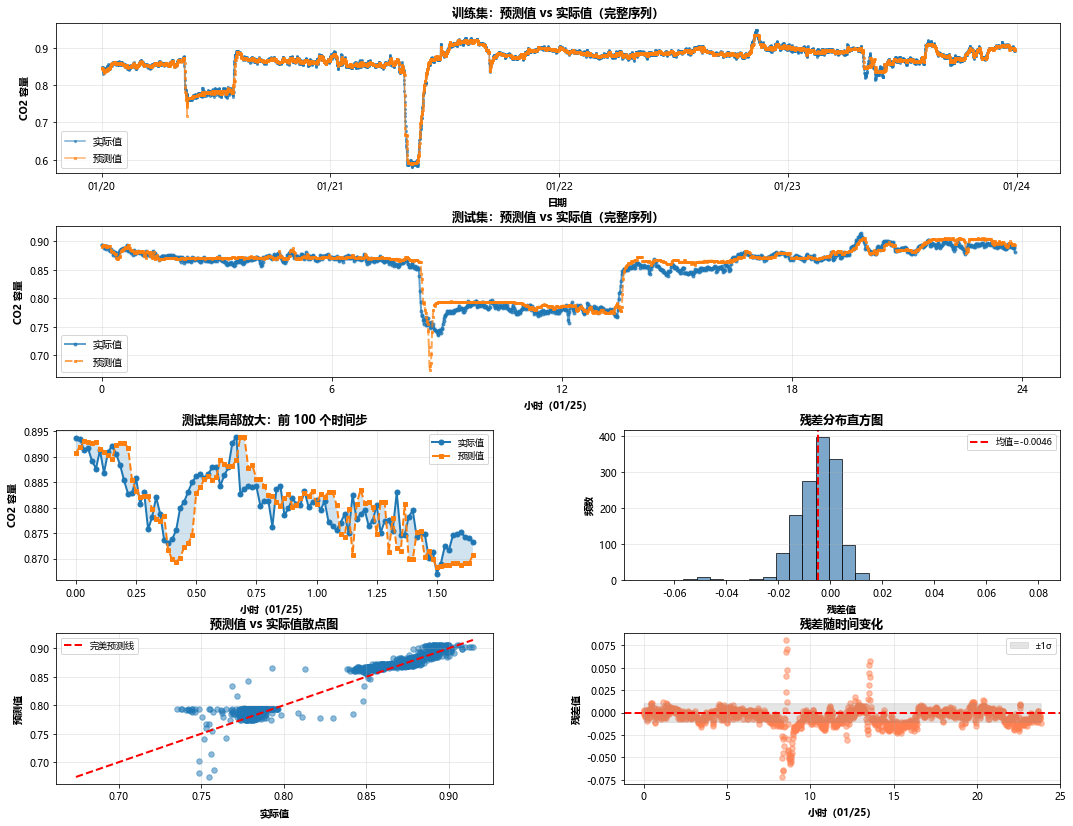

✓ 可视化图表已保存为 'time_series_prediction_results.png'
  • 训练集日期范围：01/20 到 01/24（共 5750 个数据点）
  • 测试集时间范围：01/25（共 23.82 小时）


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# 创建大图表
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)

# 训练集：创建日期序列（01/20到01/24）
train_start_date = datetime(2026, 1, 20)
train_dates = [train_start_date + timedelta(minutes=i) for i in range(len(y_train_windows))]

# 测试集：创建小时序列（0-24小时）
test_hours = np.arange(len(y_test_windows)) / 60  # 转换为小时（每分钟一个数据点）

# 图 1：训练集预测对比（完整序列）
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(train_dates, y_train_windows, 'o-', label='实际值', linewidth=1.5, markersize=2, alpha=0.6)
ax1.plot(train_dates, y_train_pred, 's-', label='预测值', linewidth=1.5, markersize=2, alpha=0.6)
ax1.set_xlabel('日期', fontweight='bold')
ax1.set_ylabel('CO2 容量', fontweight='bold')
ax1.set_title('训练集：预测值 vs 实际值（完整序列）', fontweight='bold', fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
ax1.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# 图 2：测试集预测对比（完整序列）
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(test_hours, y_test_windows, 'o-', label='实际值', linewidth=2, markersize=3, alpha=0.7)
ax2.plot(test_hours, y_test_pred, 's--', label='预测值', linewidth=2, markersize=2.5, alpha=0.7)
ax2.set_xlabel('小时（01/25）', fontweight='bold')
ax2.set_ylabel('CO2 容量', fontweight='bold')
ax2.set_title('测试集：预测值 vs 实际值（完整序列）', fontweight='bold', fontsize=12)
# 设置x轴刻度为6小时间隔
ax2.set_xticks(np.arange(0, max(test_hours)+1, 6))
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

# 图 3：测试集局部放大（前100个点）
ax3 = fig.add_subplot(gs[2, 0])
plot_range = slice(0, min(100, len(y_test_windows)))
ax3.plot(test_hours[plot_range], y_test_windows[plot_range], 'o-', label='实际值', linewidth=2, markersize=5)
ax3.plot(test_hours[plot_range], y_test_pred[plot_range], 's--', label='预测值', linewidth=2, markersize=4)
ax3.fill_between(test_hours[plot_range], y_test_windows[plot_range], y_test_pred[plot_range], alpha=0.2)
ax3.set_xlabel('小时（01/25）', fontweight='bold')
ax3.set_ylabel('CO2 容量', fontweight='bold')
ax3.set_title('测试集局部放大：前 100 个时间步', fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 图 4：残差分布
ax4 = fig.add_subplot(gs[2, 1])
ax4.hist(residuals, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax4.axvline(residuals_mean, color='red', linestyle='--', linewidth=2, label=f'均值={residuals_mean:.4f}')
ax4.set_xlabel('残差值', fontweight='bold')
ax4.set_ylabel('频数', fontweight='bold')
ax4.set_title('残差分布直方图', fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# 图 5：实际值 vs 预测值散点图
ax5 = fig.add_subplot(gs[3, 0])
ax5.scatter(y_test_windows, y_test_pred, alpha=0.5, s=30)
# 添加 45 度参考线
min_val = min(y_test_windows.min(), y_test_pred.min())
max_val = max(y_test_windows.max(), y_test_pred.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完美预测线')
ax5.set_xlabel('实际值', fontweight='bold')
ax5.set_ylabel('预测值', fontweight='bold')
ax5.set_title('预测值 vs 实际值散点图', fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

# 图 6：残差随时间变化
ax6 = fig.add_subplot(gs[3, 1])
ax6.scatter(test_hours, residuals, alpha=0.5, s=30, color='coral')
ax6.axhline(0, color='red', linestyle='--', linewidth=2)
ax6.fill_between(test_hours, -residuals_std, residuals_std, alpha=0.2, color='gray', label='±1σ')
ax6.set_xlabel('小时（01/25）', fontweight='bold')
ax6.set_ylabel('残差值', fontweight='bold')
ax6.set_title('残差随时间变化', fontweight='bold')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

plt.savefig('time_series_prediction_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ 可视化图表已保存为 'time_series_prediction_results.png'")
print(f"  • 训练集日期范围：01/20 到 01/24（共 {len(y_train_windows)} 个数据点）")
print(f"  • 测试集时间范围：01/25（共 {test_hours.max():.2f} 小时）")

## 第八步：特征重要性分析


【特征重要性分析】
            特征     总重要性    平均重要性
         TI-34 0.760092 0.076009
         TI-28 0.177034 0.017703
         TI-19 0.023605 0.002360
         TI-12 0.012758 0.001276
         TI-33 0.011580 0.001158
         TI-22 0.005135 0.000513
          TI-4 0.003939 0.000394
Level Reboiler 0.002528 0.000253
         TI-24 0.002048 0.000205
         FI-30 0.000740 0.000074
         FI-38 0.000540 0.000054


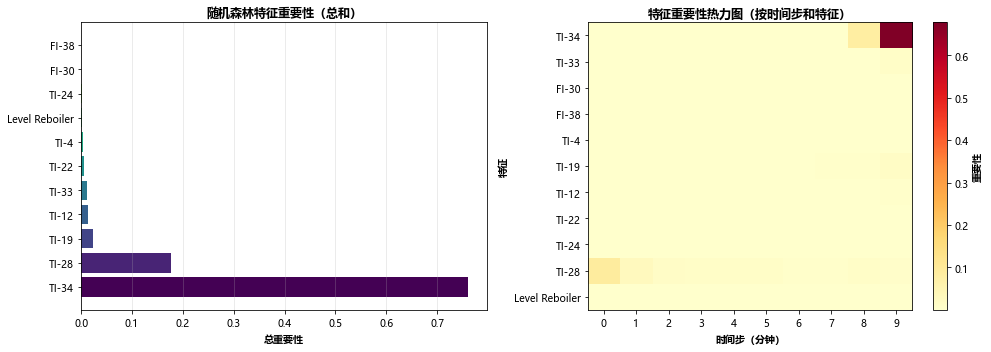


✓ 特征重要性图表已保存为 'feature_importance_analysis.png'


In [10]:
# 获取特征重要性
feature_importance = rf_model.feature_importances_

# 由于输入是展平的窗口，需要重新组织
# 形状：(10 分钟 × 10 特征) = 100 维
n_features_per_window = len(selected_features)  # 10
window_size = 10

# 按时间步和特征分组重要性
importance_matrix = feature_importance.reshape(window_size, n_features_per_window)

# 计算各特征在所有时间步的总重要性
feature_total_importance = importance_matrix.sum(axis=0)
feature_importance_df = pd.DataFrame({
    '特征': selected_features,
    '总重要性': feature_total_importance,
    '平均重要性': feature_total_importance / window_size
}).sort_values('总重要性', ascending=False)

print("\n【特征重要性分析】")
print(feature_importance_df.to_string(index=False))

# 可视化特征重要性
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图 1：特征总重要性条形图
ax1 = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))
bars = ax1.barh(range(len(feature_importance_df)), feature_importance_df['总重要性'], color=colors)
ax1.set_yticks(range(len(feature_importance_df)))
ax1.set_yticklabels(feature_importance_df['特征'])
ax1.set_xlabel('总重要性', fontweight='bold')
ax1.set_title('随机森林特征重要性（总和）', fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# 图 2：特征重要性随时间步变化的热力图
ax2 = axes[1]
im = ax2.imshow(importance_matrix.T, aspect='auto', cmap='YlOrRd')
ax2.set_xlabel('时间步（分钟）', fontweight='bold')
ax2.set_ylabel('特征', fontweight='bold')
ax2.set_xticks(range(window_size))
ax2.set_yticks(range(len(selected_features)))
ax2.set_yticklabels(selected_features)
ax2.set_title('特征重要性热力图（按时间步和特征）', fontweight='bold')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('重要性', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ 特征重要性图表已保存为 'feature_importance_analysis.png'")

## 第九步：结果汇总与保存

In [11]:
# 创建汇总报告
summary_report = f"""
{'='*80}
时序预测模型性能总结报告
{'='*80}

【数据配置】
  • 原始数据点数：{len(df)}
  • 采样频率：1 分钟/条
  • 时间跨度：约 {len(df)} 分钟
  • 选定特征数：{len(selected_features)}

【数据分割】
  • 训练集：{len(X_train_raw)} 条（前 80%）
  • 测试集：{len(X_test_raw)} 条（后 20%）
  • 训练窗口数：{len(X_train_windows)}（每个窗口 10 分钟）
  • 测试窗口数：{len(X_test_windows)}（每个窗口 10 分钟）

【模型配置】
  • 模型类型：随机森林回归器
  • 树的数量：{rf_model.n_estimators}
  • 输入特征维度：{X_train_windows.shape[1]}（10 分钟 × {len(selected_features)} 特征）
  • 预测任务：前 10 分钟 → 下 1 分钟

【性能指标】

  训练集：
    • R²：{train_r2:.4f}
    • RMSE：{train_rmse:.6f}
    • MAE：{train_mae:.6f}
    • WQL：{train_wql:.6f}

  测试集：
    • R²：{test_r2:.4f}
    • RMSE：{test_rmse:.6f}
    • MAE：{test_mae:.6f}
    • WQL：{test_wql:.6f}

【性能指标详解】
  • R²（决定系数）：模型解释的方差比例，范围 [0, 1]，越接近 1 越好
  • RMSE（均方根误差）：预测偏差的平方和再开方，对大偏差更敏感
  • MAE（平均绝对误差）：预测偏差的平均值，更鲁棒性强
  • WQL（加权分位数损失）：衡量预测偏差的对称性和平衡性
    └─ 当预测值 < 实际值时（预测偏低），损失权重为 0.5
    └─ 当预测值 > 实际值时（预测偏高），损失权重为 0.5
    └─ WQL 越小表示预测越平衡，没有系统偏差

【预测精度解释】
  • R² = {test_r2:.4f}：模型解释了测试集 {test_r2*100:.2f}% 的目标变量方差
  • RMSE = {test_rmse:.6f}：平均预测误差（在原始数据尺度上）
  • MAE = {test_mae:.6f}：平均绝对偏差
  • WQL = {test_wql:.6f}：预测的平衡性指标（接近 0 为好）

【残差分析】
  • 残差均值：{residuals_mean:.6f}（接近 0 表示预测无偏）
  • 残差标准差：{residuals_std:.6f}
  • 残差范围：[{residuals.min():.6f}, {residuals.max():.6f}]

【Top 5 重要特征】
  • {feature_importance_df.iloc[0]['特征']}：{feature_importance_df.iloc[0]['总重要性']:.4f}
  • {feature_importance_df.iloc[1]['特征']}：{feature_importance_df.iloc[1]['总重要性']:.4f}
  • {feature_importance_df.iloc[2]['特征']}：{feature_importance_df.iloc[2]['总重要性']:.4f}
  • {feature_importance_df.iloc[3]['特征']}：{feature_importance_df.iloc[3]['总重要性']:.4f}
  • {feature_importance_df.iloc[4]['特征']}：{feature_importance_df.iloc[4]['总重要性']:.4f}

{'='*80}
"""

print(summary_report)

# 保存报告
with open('time_series_prediction_report.txt', 'w', encoding='utf-8') as f:
    f.write(summary_report)
print("✓ 报告已保存为 'time_series_prediction_report.txt'")


时序预测模型性能总结报告

【数据配置】
  • 原始数据点数：7200
  • 采样频率：1 分钟/条
  • 时间跨度：约 7200 分钟
  • 选定特征数：11

【数据分割】
  • 训练集：5760 条（前 80%）
  • 测试集：1440 条（后 20%）
  • 训练窗口数：5750（每个窗口 10 分钟）
  • 测试窗口数：1430（每个窗口 10 分钟）

【模型配置】
  • 模型类型：随机森林回归器
  • 树的数量：400
  • 输入特征维度：110（10 分钟 × 11 特征）
  • 预测任务：前 10 分钟 → 下 1 分钟

【性能指标】

  训练集：
    • R²：0.9882
    • RMSE：0.005040
    • MAE：0.002902
    • WQL：0.001451

  测试集：
    • R²：0.9253
    • RMSE：0.011367
    • MAE：0.007446
    • WQL：0.003723

【性能指标详解】
  • R²（决定系数）：模型解释的方差比例，范围 [0, 1]，越接近 1 越好
  • RMSE（均方根误差）：预测偏差的平方和再开方，对大偏差更敏感
  • MAE（平均绝对误差）：预测偏差的平均值，更鲁棒性强
  • WQL（加权分位数损失）：衡量预测偏差的对称性和平衡性
    └─ 当预测值 < 实际值时（预测偏低），损失权重为 0.5
    └─ 当预测值 > 实际值时（预测偏高），损失权重为 0.5
    └─ WQL 越小表示预测越平衡，没有系统偏差

【预测精度解释】
  • R² = 0.9253：模型解释了测试集 92.53% 的目标变量方差
  • RMSE = 0.011367：平均预测误差（在原始数据尺度上）
  • MAE = 0.007446：平均绝对偏差
  • WQL = 0.003723：预测的平衡性指标（接近 0 为好）

【残差分析】
  • 残差均值：-0.004600（接近 0 表示预测无偏）
  • 残差标准差：0.010395
  • 残差范围：[-0.071741, 0.080842]

【Top 5 重要特征】
  • TI-34：0.7601
  • TI-28：0.1770
  • T

In [12]:
# 保存预测结果为 CSV
results_df = pd.DataFrame({
    '时间步': np.arange(len(y_test_windows)),
    '实际值': y_test_windows,
    '预测值': y_test_pred,
    '残差': residuals,
    '绝对误差': np.abs(residuals),
    '相对误差(%)': np.abs(residuals) / np.abs(y_test_windows) * 100
})

results_df.to_csv('time_series_predictions.csv', index=False, encoding='utf-8-sig')
print("✓ 预测结果已保存为 'time_series_predictions.csv'")

# 保存性能指标汇总
metrics_summary = pd.DataFrame({
    '指标': ['R²', 'RMSE', 'MAE', '残差均值', '残差标准差'],
    '训练集': [train_r2, train_rmse, train_mae, np.nan, np.nan],
    '测试集': [test_r2, test_rmse, test_mae, residuals_mean, residuals_std]
})

metrics_summary.to_csv('performance_metrics.csv', index=False, encoding='utf-8-sig')
print("✓ 性能指标已保存为 'performance_metrics.csv'")

print("\n" + "="*80)
print("✅ 所有文件生成完成！")
print("="*80)
print("\n生成的文件：")
print("  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）")
print("  2. feature_importance_analysis.png - 特征重要性分析")
print("  3. time_series_prediction_report.txt - 性能汇总报告")
print("  4. time_series_predictions.csv - 详细预测结果")
print("  5. performance_metrics.csv - 性能指标汇总")

✓ 预测结果已保存为 'time_series_predictions.csv'
✓ 性能指标已保存为 'performance_metrics.csv'

✅ 所有文件生成完成！

生成的文件：
  1. time_series_prediction_results.png - 预测结果可视化（5 个子图）
  2. feature_importance_analysis.png - 特征重要性分析
  3. time_series_prediction_report.txt - 性能汇总报告
  4. time_series_predictions.csv - 详细预测结果
  5. performance_metrics.csv - 性能指标汇总


## 第八步：SHAP可解释性分析

**SHAP (SHapley Additive exPlanations)** 是一种模型可解释性工具，用于解释机器学习模型的预测结果。

### 📊 两种重要图表：

1. **总结图 (Summary Plot)** - 全局视角
   - 展示所有特征对模型预测的整体影响
   - 横轴：SHAP值（特征贡献）
   - 纵轴：特征名称（按重要性排序）
   - 颜色：特征值高低（红=高，蓝=低）
   - **用途**：找出最重要的特征，了解特征如何影响预测

2. **瀑布图 (Waterfall Plot)** - 单样本视角
   - 展示单个预测是如何计算出来的
   - 从基准值开始，逐步累加每个特征的贡献
   - 红色：正向贡献（推高预测）
   - 蓝色：负向贡献（拉低预测）
   - **用途**：解释具体某个时刻的预测结果，诊断异常

In [13]:
# 第1步：创建有意义的特征名称
print("="*80)
print("开始SHAP可解释性分析")
print("="*80)

# 生成特征名称：每个原始特征在10个时间步上的名称
feature_names = []
for t in range(10, 0, -1):  # 从 t-10 到 t-1
    for feat in selected_features:
        feature_names.append(f'{feat}_t-{t}')

print(f"\n✓ 生成了 {len(feature_names)} 个特征名称")
print(f"  示例：{feature_names[:5]}")
print(f"        {feature_names[-5:]}")

# 创建带特征名的DataFrame（用于SHAP分析）
X_train_df = pd.DataFrame(X_train_windows, columns=feature_names)
X_test_df = pd.DataFrame(X_test_windows, columns=feature_names)

print(f"\n训练集形状：{X_train_df.shape}")
print(f"测试集形状：{X_test_df.shape}")

开始SHAP可解释性分析

✓ 生成了 110 个特征名称
  示例：['TI-34_t-10', 'TI-33_t-10', 'FI-30_t-10', 'FI-38_t-10', 'TI-4_t-10']
        ['TI-12_t-1', 'TI-22_t-1', 'TI-24_t-1', 'TI-28_t-1', 'Level Reboiler_t-1']

训练集形状：(5750, 110)
测试集形状：(1430, 110)


In [14]:
# 第2步：创建SHAP TreeExplainer（专门针对树模型，速度快）
print("\n" + "="*80)
print("创建SHAP TreeExplainer")
print("="*80)

# 使用背景数据集（随机抽取100个样本加速计算）
background_data = shap.sample(X_train_df, 100, random_state=42)
print(f"✓ 背景数据集：{background_data.shape[0]} 个样本")

# 创建TreeExplainer
explainer = shap.TreeExplainer(rf_model, background_data)
print(f"✓ TreeExplainer 创建完成")
print(f"  • 模型类型：{type(rf_model).__name__}")
print(f"  • 特征数量：{len(feature_names)}")


创建SHAP TreeExplainer
✓ 背景数据集：100 个样本
✓ TreeExplainer 创建完成
  • 模型类型：RandomForestRegressor
  • 特征数量：110


In [15]:
# 第3步：合并训练集和测试集，计算全部样本的SHAP值
print("\n" + "="*80)
print("合并数据集并计算SHAP值")
print("="*80)

# 合并训练集和测试集
print(f"\n【数据集合并】")
print(f"  • 训练集样本数：{len(X_train_df)}")
print(f"  • 测试集样本数：{len(X_test_df)}")

# 合并DataFrame
X_all_df = pd.concat([X_train_df, X_test_df], axis=0, ignore_index=True)
y_all = np.concatenate([y_train_windows, y_test_windows])

print(f"  • 合并后总样本数：{len(X_all_df)}")

# 计算预测值用于后续分析
y_all_pred = rf_model.predict(X_all_df)

print(f"  • 实际值范围：[{y_all.min():.6f}, {y_all.max():.6f}]")
print(f"  • 预测值范围：[{y_all_pred.min():.6f}, {y_all_pred.max():.6f}]")

# 使用全部样本计算SHAP值
print(f"\n正在计算 {len(X_all_df)} 个样本的SHAP值...")

shap_values_all = explainer.shap_values(X_all_df)
print(f"  • 基准值（Expected value）：{explainer.expected_value:.6f}")

print(f"  • SHAP值形状：{shap_values_all.shape}")
print(f"✓ SHAP值计算完成")


合并数据集并计算SHAP值

【数据集合并】
  • 训练集样本数：5750
  • 测试集样本数：1430
  • 合并后总样本数：7180
  • 实际值范围：[0.582062, 0.948009]
  • 预测值范围：[0.589955, 0.933656]

正在计算 7180 个样本的SHAP值...


100%|===================| 7178/7180 [03:09<00:00]        

  • 基准值（Expected value）：0.867666
  • SHAP值形状：(7180, 110)
✓ SHAP值计算完成



绘制SHAP总结图（按原始特征聚合）
✓ SHAP值已按11个原始特征聚合
  • 聚合后形状：(7180, 11)


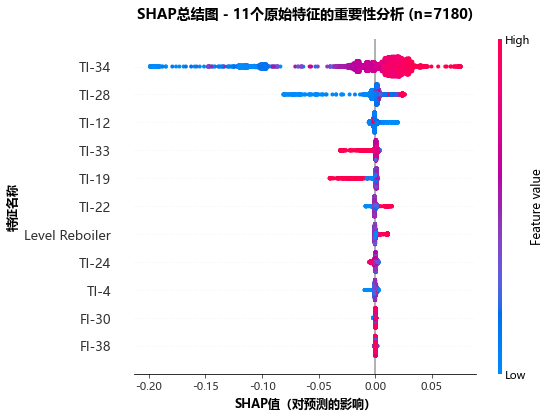

✓ SHAP总结图已保存：shap_summary_plot_combined.png

【图表说明】
  • 样本来源：训练集 + 测试集合并后的全部样本
  • 横轴：SHAP值（特征对预测的贡献，正值推高预测，负值拉低预测）
  • 纵轴：11个原始特征名称（按重要性从上到下排序）
  • 颜色：特征值大小（红色=高值，蓝色=低值）
  • 说明：每个特征的SHAP值是其在10个时间步上的总和
  • 用途：识别最重要的特征，了解特征值如何影响CO2容量预测


In [16]:
# 第4步：绘制SHAP总结图（按11个原始特征聚合）
print("\n" + "="*80)
print("绘制SHAP总结图（按原始特征聚合）")
print("="*80)

# 将110维SHAP值按11个原始特征聚合
shap_values_aggregated = np.zeros((shap_values_all.shape[0], len(selected_features)))
X_all_aggregated = np.zeros((X_all_df.shape[0], len(selected_features)))

for i, feat in enumerate(selected_features):
    # 找到该特征在不同时间步的所有列索引
    feat_indices = [idx for idx, name in enumerate(feature_names) if name.startswith(feat + '_')]
    # 聚合SHAP值（求和）
    shap_values_aggregated[:, i] = shap_values_all[:, feat_indices].sum(axis=1)
    # 聚合特征值（取平均）
    X_all_aggregated[:, i] = X_all_df.iloc[:, feat_indices].mean(axis=1)

print(f"✓ SHAP值已按11个原始特征聚合")
print(f"  • 聚合后形状：{shap_values_aggregated.shape}")

# 绘制聚合后的总结图
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_aggregated, 
    pd.DataFrame(X_all_aggregated, columns=selected_features),
    show=False
)
plt.title(f'SHAP总结图 - 11个原始特征的重要性分析 (n={len(X_all_df)})', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('SHAP值（对预测的影响）', fontsize=12, fontweight='bold')
plt.ylabel('特征名称', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ SHAP总结图已保存：shap_summary_plot_combined.png")
print(f"\n【图表说明】")
print(f"  • 样本来源：训练集 + 测试集合并后的全部样本")
print(f"  • 横轴：SHAP值（特征对预测的贡献，正值推高预测，负值拉低预测）")
print(f"  • 纵轴：11个原始特征名称（按重要性从上到下排序）")
print(f"  • 颜色：特征值大小（红色=高值，蓝色=低值）")

print(f"  • 说明：每个特征的SHAP值是其在10个时间步上的总和")
print(f"  • 用途：识别最重要的特征，了解特征值如何影响CO2容量预测")

In [18]:
# 第5步：选择典型样本绘制瀑布图
print("\n" + "="*80)
print("选择典型样本绘制SHAP瀑布图")
print("="*80)

# 从合并数据集中选择典型样本
errors = y_all - y_all_pred
abs_errors = np.abs(errors)

# 选择3个典型样本
max_actual_idx = np.argmax(y_all)
min_actual_idx = np.argmin(y_all)
min_error_idx = np.argmin(abs_errors)

typical_samples = [
    ('实际值最大点', max_actual_idx, 'blue'),
    ('实际值最小点', min_actual_idx, 'purple'),
    ('预测最准的点', min_error_idx, 'green')
]

print(f"\n已选择3个典型样本：")
for name, idx, color in typical_samples:
    print(f"  • {name}：样本索引={idx}, 实际值={y_all[idx]:.6f}, "
          f"预测值={y_all_pred[idx]:.6f}, 误差={errors[idx]:.6f}")


选择典型样本绘制SHAP瀑布图

已选择3个典型样本：
  • 实际值最大点：样本索引=4123, 实际值=0.948009, 预测值=0.933227, 误差=0.014782
  • 实际值最小点：样本索引=1954, 实际值=0.582062, 预测值=0.589955, 误差=-0.007892
  • 预测最准的点：样本索引=1948, 实际值=0.590589, 预测值=0.590589, 误差=-0.000000



绘制SHAP瀑布图（3个典型样本，按11个原始特征聚合）

【SHAP值统计信息】
  • 基准值（Expected value）：0.867666
  • 合并数据集预测值范围：[0.589955, 0.933656]
  • 合并数据集实际值范围：[0.582062, 0.948009]

【SHAP值验证（第1个样本）】
  • 基准值：0.867666
  • 所有SHAP值之和：-0.022645
  • 基准值 + SHAP和：0.845021
  • 实际预测值：0.845021
  • 差异：0.000000

正在绘制第 1 张图：实际值最大点...

【聚合后的SHAP值（第1个典型样本：实际值最大点）】
  • 聚合后SHAP值范围：[-0.009010, 0.074790]
  • 聚合后SHAP值总和：0.065561
  • 各特征的SHAP值：
      TI-34          :   0.074790
      TI-33          :  -0.009010
      FI-30          :   0.000076
      FI-38          :  -0.000008
      TI-4           :  -0.000157
      TI-19          :   0.001679
      TI-12          :  -0.000148
      TI-22          :  -0.000310
      TI-24          :  -0.000593
      TI-28          :  -0.001199
      Level Reboiler :   0.000442


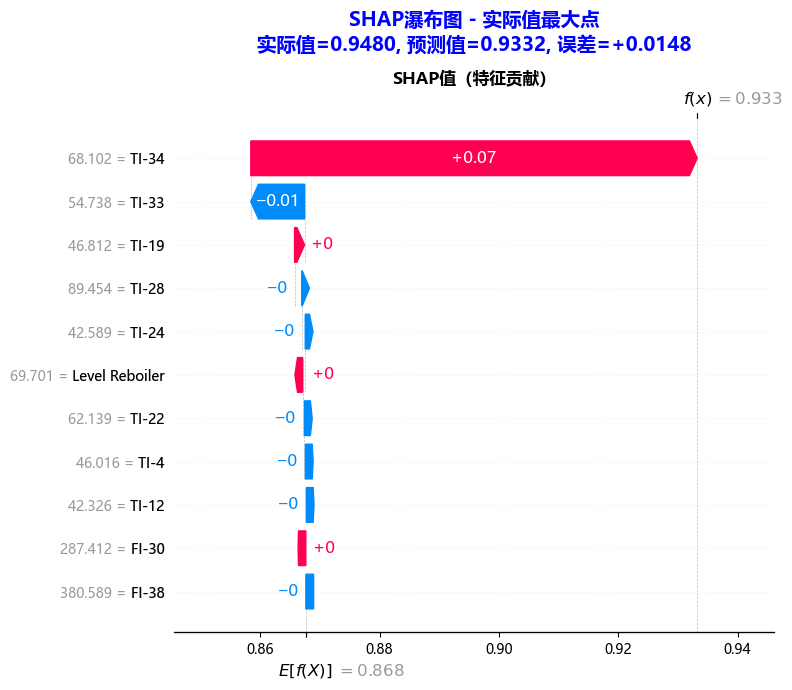

  ✓ 已保存：shap_waterfall_1_实际值最大点.png

正在绘制第 2 张图：实际值最小点...


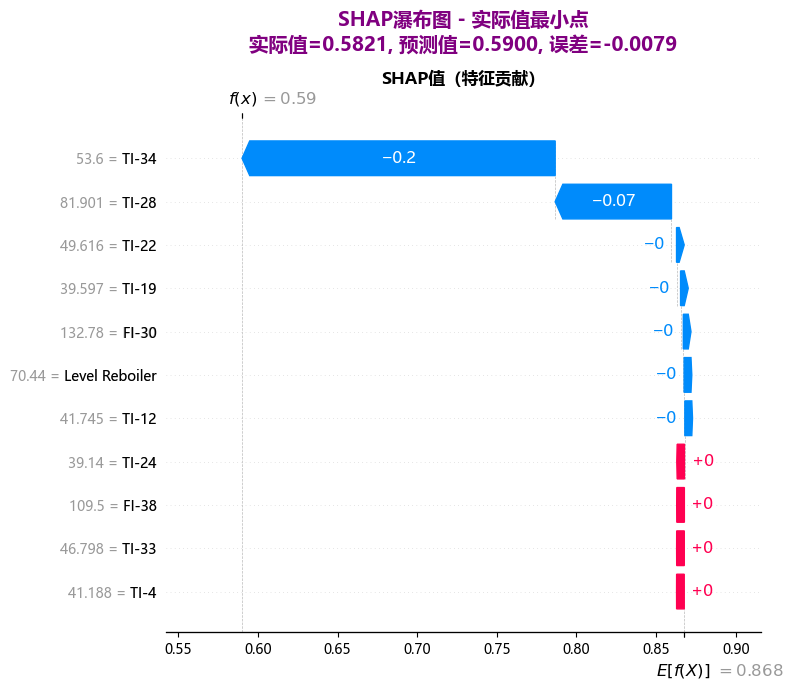

  ✓ 已保存：shap_waterfall_2_实际值最小点.png

正在绘制第 3 张图：预测最准的点...


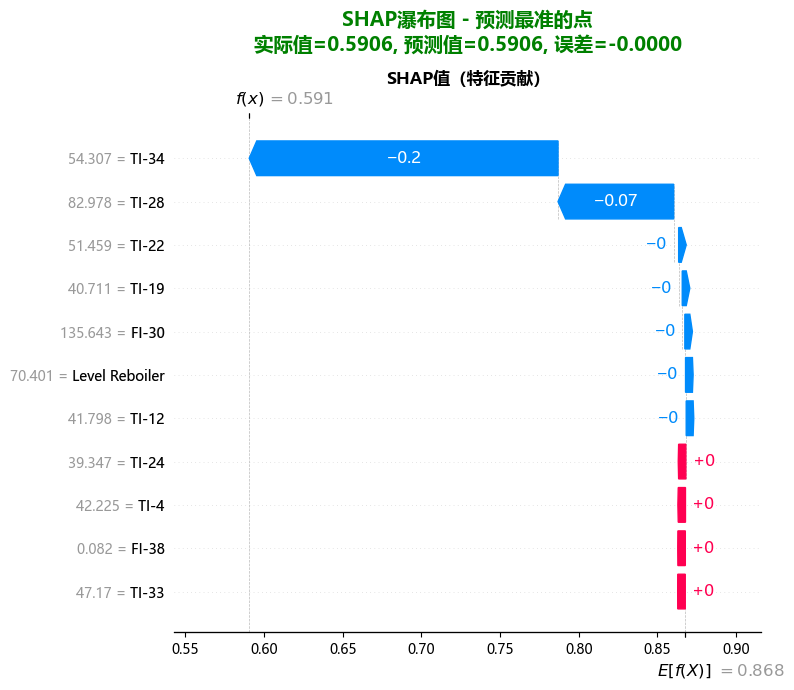

  ✓ 已保存：shap_waterfall_3_预测最准的点.png

✓ 所有SHAP瀑布图已保存：
    - shap_waterfall_1_实际值最大点.png
    - shap_waterfall_2_实际值最小点.png
    - shap_waterfall_3_预测最准的点.png

【图表说明】
  • E[f(x)]：基准值（所有样本的平均预测值=0.8677）
  • f(x)：该样本的实际预测值
  • 红色条：正向贡献（推高预测）
  • 蓝色条：负向贡献（拉低预测）
  • 误差：正值表示高估（预测>实际），负值表示低估（预测<实际）
  • 用途：解释单个预测的计算过程，诊断异常样本

【样本类型】
  • 实际值最大点：CO2容量最高的样本，了解高容量时的特征影响
  • 实际值最小点：CO2容量最低的样本，了解低容量时的特征影响
  • 预测最准的点：误差最小的样本，了解模型预测最佳时的情况


In [19]:
# 第6步：绘制瀑布图（3个典型样本）
print("\n" + "="*80)
print("绘制SHAP瀑布图（3个典型样本，按11个原始特征聚合）")
print("="*80)

# 设置白色背景样式
plt.style.use('default')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 使用ASCII减号，兼容性更好
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# 首先打印SHAP值的统计信息
print(f"\n【SHAP值统计信息】")
print(f"  • 基准值（Expected value）：{explainer.expected_value:.6f}")
print(f"  • 合并数据集预测值范围：[{y_all_pred.min():.6f}, {y_all_pred.max():.6f}]")
print(f"  • 合并数据集实际值范围：[{y_all.min():.6f}, {y_all.max():.6f}]")

# 验证第一个样本的SHAP值
idx_check = 0
shap_sum_check = shap_values_all[idx_check].sum()
pred_check = y_all_pred[idx_check]
print(f"\n【SHAP值验证（第1个样本）】")
print(f"  • 基准值：{explainer.expected_value:.6f}")
print(f"  • 所有SHAP值之和：{shap_sum_check:.6f}")
print(f"  • 基准值 + SHAP和：{explainer.expected_value + shap_sum_check:.6f}")
print(f"  • 实际预测值：{pred_check:.6f}")
print(f"  • 差异：{abs((explainer.expected_value + shap_sum_check) - pred_check):.6f}")

# 为每个典型样本绘制单独的瀑布图
saved_files = []
for i, (name, idx, color) in enumerate(typical_samples, 1):
    print(f"\n正在绘制第 {i} 张图：{name}...")
    
    # 创建新的独立图形
    fig = plt.figure(figsize=(10, 8))
    fig.patch.set_facecolor('white')
    ax = plt.gca()
    ax.set_facecolor('white')
    
    # 对该样本的SHAP值按11个原始特征聚合
    shap_values_aggregated_sample = np.zeros(len(selected_features))
    X_aggregated_sample = np.zeros(len(selected_features))
    
    for j, feat in enumerate(selected_features):
        # 找到该特征在不同时间步的所有列索引
        feat_indices = [k for k, name_k in enumerate(feature_names) if name_k.startswith(feat + '_')]
        # 聚合SHAP值（求和）
        shap_values_aggregated_sample[j] = shap_values_all[idx, feat_indices].sum()
        # 聚合特征值（取平均）
        X_aggregated_sample[j] = X_all_df.iloc[idx, feat_indices].mean()
    
    # 打印聚合后的SHAP值信息（只打印第一个样本）
    if i == 1:
        print(f"\n【聚合后的SHAP值（第1个典型样本：{name}）】")
        print(f"  • 聚合后SHAP值范围：[{shap_values_aggregated_sample.min():.6f}, {shap_values_aggregated_sample.max():.6f}]")
        print(f"  • 聚合后SHAP值总和：{shap_values_aggregated_sample.sum():.6f}")
        print(f"  • 各特征的SHAP值：")
        for feat_name, shap_val in zip(selected_features, shap_values_aggregated_sample):
            print(f"      {feat_name:<15}: {shap_val:>10.6f}")
    
    # 创建SHAP Explanation对象（使用聚合后的11个特征）
    shap_exp = shap.Explanation(
        values=shap_values_aggregated_sample,
        base_values=explainer.expected_value,
        data=X_aggregated_sample,
        feature_names=selected_features
    )
    
    # 绘制瀑布图
    shap.waterfall_plot(shap_exp, max_display=11, show=False)
    
    # 添加中文标题和说明
    actual = y_all[idx]
    pred = y_all_pred[idx]
    error = errors[idx]
    
    # 根据样本类型设置不同的标题颜色
    plt.title(f'SHAP瀑布图 - {name}\n实际值={actual:.4f}, 预测值={pred:.4f}, 误差={error:+.4f}',
              fontsize=14, fontweight='bold', color=color, pad=15)
    plt.xlabel('SHAP值（特征贡献）', fontsize=12, fontweight='bold')
    plt.ylabel('特征', fontsize=12, fontweight='bold')
    
    # 调整字体大小
    ax.tick_params(axis='both', which='major', labelsize=10)
    
    # 保存为单独的文件
    filename = f'shap_waterfall_{i}_{name.replace(" ", "_")}.png'
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    saved_files.append(filename)
    print(f"  ✓ 已保存：{filename}")
    
    # 关闭当前图形释放内存
    plt.close(fig)

print(f"\n✓ 所有SHAP瀑布图已保存：")
for filename in saved_files:
    print(f"    - {filename}")
print(f"\n【图表说明】")
print(f"  • E[f(x)]：基准值（所有样本的平均预测值={explainer.expected_value:.4f}）")
print(f"  • f(x)：该样本的实际预测值")
print(f"  • 红色条：正向贡献（推高预测）")
print(f"  • 蓝色条：负向贡献（拉低预测）")
print(f"  • 误差：正值表示高估（预测>实际），负值表示低估（预测<实际）")
print(f"  • 用途：解释单个预测的计算过程，诊断异常样本")
print(f"\n【样本类型】")
print(f"  • 实际值最大点：CO2容量最高的样本，了解高容量时的特征影响")
print(f"  • 实际值最小点：CO2容量最低的样本，了解低容量时的特征影响")
print(f"  • 预测最准的点：误差最小的样本，了解模型预测最佳时的情况")

In [20]:
# 第7步：SHAP分析总结报告
print("\n" + "="*80)
print("SHAP分析总结报告")
print("="*80)

# 计算平均绝对SHAP值，找出最重要的特征
mean_abs_shap = np.abs(shap_values_all).mean(axis=0)

# 按重要性排序
top_n = 10
top_indices = np.argsort(mean_abs_shap)[::-1][:top_n]

print(f"\n【合并数据集】Top {top_n} 最重要特征（按平均|SHAP值|排序）：")
for rank, idx in enumerate(top_indices, 1):
    print(f"  {rank}. {feature_names[idx]:<20} | 平均|SHAP|={mean_abs_shap[idx]:.6f}")

# 保存SHAP重要性到CSV
shap_importance_df = pd.DataFrame({
    '特征名称': feature_names,
    '平均绝对SHAP值': mean_abs_shap
})
shap_importance_df = shap_importance_df.sort_values('平均绝对SHAP值', ascending=False)
shap_importance_df.to_csv('shap_feature_importance.csv', index=False, encoding='utf-8-sig')

print(f"\n✓ SHAP特征重要性已保存：shap_feature_importance.csv")

print("\n" + "="*80)
print("✅ SHAP分析完成！")
print("="*80)
print("\n生成的文件：")
print("  1. shap_summary_plot_combined.png - 合并数据集SHAP总结图")
print("  2. shap_waterfall_plots_combined.png - 典型样本瀑布图（3个）")
print("  3. shap_feature_importance.csv - SHAP特征重要性排名")

print("\n【SHAP分析总结】")
print(f"  • 模型类型：{type(rf_model).__name__}")
print(f"  • 数据来源：训练集 + 测试集合并（总计{len(X_all_df)}个样本）")
print(f"  • 分析数量：{len(X_all_df)}个样本（全部样本）")
print(f"  • 特征维度：{len(selected_features)}个原始特征 × 10个时间步 = {len(feature_names)}维")
print(f"  • SHAP值聚合：按{len(selected_features)}个原始特征求和，保留时间序列信息")
print(f"  • 可解释性工具：总结图（全局） + 瀑布图（单样本）")


SHAP分析总结报告

【合并数据集】Top 10 最重要特征（按平均|SHAP值|排序）：
  1. TI-34_t-1            | 平均|SHAP|=0.025585
  2. TI-34_t-2            | 平均|SHAP|=0.002351
  3. TI-28_t-10           | 平均|SHAP|=0.001618
  4. TI-33_t-1            | 平均|SHAP|=0.001185
  5. TI-19_t-1            | 平均|SHAP|=0.001013
  6. TI-28_t-9            | 平均|SHAP|=0.000616
  7. TI-22_t-9            | 平均|SHAP|=0.000524
  8. TI-12_t-1            | 平均|SHAP|=0.000415
  9. TI-28_t-5            | 平均|SHAP|=0.000395
  10. TI-28_t-6            | 平均|SHAP|=0.000368

✓ SHAP特征重要性已保存：shap_feature_importance.csv

✅ SHAP分析完成！

生成的文件：
  1. shap_summary_plot_combined.png - 合并数据集SHAP总结图
  2. shap_waterfall_plots_combined.png - 典型样本瀑布图（3个）
  3. shap_feature_importance.csv - SHAP特征重要性排名

【SHAP分析总结】
  • 模型类型：RandomForestRegressor
  • 数据来源：训练集 + 测试集合并（总计7180个样本）
  • 分析数量：7180个样本（全部样本）
  • 特征维度：11个原始特征 × 10个时间步 = 110维
  • SHAP值聚合：按11个原始特征求和，保留时间序列信息
  • 可解释性工具：总结图（全局） + 瀑布图（单样本）


## 敏感性分析：TI-34对测试集的影响

**分析目标：**
- 分析TI-34特征对模型预测的影响
- 时间范围：测试集6点到12点（6小时 = 360分钟）
- 方法：用TI-34的平均值替换原始值，观察预测结果的变化

**分析步骤：**
1. 提取6-12点的测试集数据
2. 绘制TI-34原始值的时间序列图
3. 计算TI-34的平均值
4. 用平均值替换所有TI-34值
5. 重新构造滑动窗口并预测
6. 对比原始预测和敏感性测试预测的差异

In [21]:
# 第1步：提取测试集6点到12点的数据范围
print("="*80)
print("敏感性分析：TI-34特征对预测的影响")
print("="*80)

# 测试集时间范围设定
# 测试集是从原始数据的split_idx开始的
# 每分钟一个数据点，6点 = 6*60 = 360分钟，12点 = 12*60 = 720分钟
start_hour = 6
end_hour = 12
start_min = start_hour * 60  # 360分钟
end_min = end_hour * 60      # 720分钟

print(f"\n【时间范围】")
print(f"  • 分析时间段：{start_hour}:00 - {end_hour}:00")
print(f"  • 对应索引：第 {start_min} 到第 {end_min} 分钟")

# 从原始测试数据中提取6-12点的数据
# 注意：滑动窗口会减少10个样本，所以需要从X_test_raw中提取
X_test_6_12_raw = X_test_raw.iloc[start_min:end_min].copy()
y_test_6_12_raw = y_test_raw.iloc[start_min:end_min].copy()

print(f"\n【数据提取】")
print(f"  • 原始测试集大小：{len(X_test_raw)} 条")
print(f"  • 6-12点数据大小：{len(X_test_6_12_raw)} 条")
print(f"  • TI-34在选定特征中的位置：索引 {selected_features.index('TI-34')}")

# 提取TI-34的值
ti34_values = X_test_6_12_raw['TI-34'].values
ti34_mean = ti34_values.mean()
ti34_std = ti34_values.std()

print(f"\n【TI-34统计信息（6-12点）】")
print(f"  • 样本数：{len(ti34_values)}")
print(f"  • 平均值：{ti34_mean:.6f}")
print(f"  • 标准差：{ti34_std:.6f}")
print(f"  • 最小值：{ti34_values.min():.6f}")
print(f"  • 最大值：{ti34_values.max():.6f}")

敏感性分析：TI-34特征对预测的影响

【时间范围】
  • 分析时间段：6:00 - 12:00
  • 对应索引：第 360 到第 720 分钟

【数据提取】
  • 原始测试集大小：1440 条
  • 6-12点数据大小：360 条
  • TI-34在选定特征中的位置：索引 0

【TI-34统计信息（6-12点）】
  • 样本数：360
  • 平均值：60.384742
  • 标准差：2.889625
  • 最小值：56.710361
  • 最大值：64.136719



绘制TI-34原始值（6-12点）


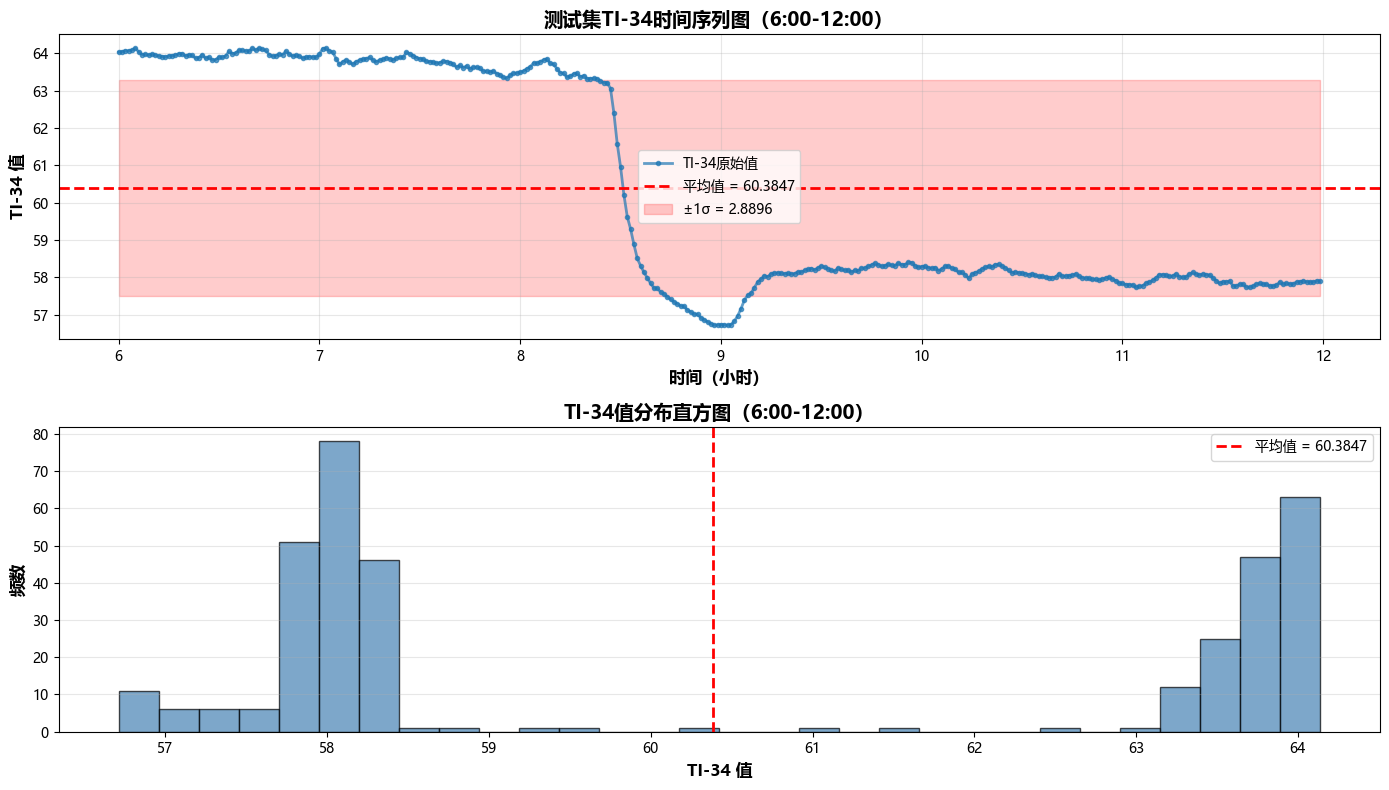

✓ TI-34原始值图表已保存：sensitivity_TI34_original_values.png


In [22]:
# 第2步：绘制TI-34原始值的时间序列图
print("\n" + "="*80)
print("绘制TI-34原始值（6-12点）")
print("="*80)

# 创建时间轴（分钟）
time_minutes = np.arange(len(ti34_values))
time_hours = time_minutes / 60 + start_hour  # 转换为小时，从6点开始

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 图1：TI-34时间序列图
ax1 = axes[0]
ax1.plot(time_hours, ti34_values, 'o-', linewidth=2, markersize=3, alpha=0.7, label='TI-34原始值')
ax1.axhline(ti34_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti34_mean:.4f}')
ax1.fill_between(time_hours, ti34_mean - ti34_std, ti34_mean + ti34_std, 
                  alpha=0.2, color='red', label=f'±1σ = {ti34_std:.4f}')
ax1.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax1.set_ylabel('TI-34 值', fontsize=12, fontweight='bold')
ax1.set_title('测试集TI-34时间序列图（6:00-12:00）', fontsize=14, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 图2：TI-34分布直方图
ax2 = axes[1]
ax2.hist(ti34_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax2.axvline(ti34_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti34_mean:.4f}')
ax2.set_xlabel('TI-34 值', fontsize=12, fontweight='bold')
ax2.set_ylabel('频数', fontsize=12, fontweight='bold')
ax2.set_title('TI-34值分布直方图（6:00-12:00）', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sensitivity_TI34_original_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ TI-34原始值图表已保存：sensitivity_TI34_original_values.png")

In [23]:
# 第3步：创建敏感性测试数据集（用平均值替换TI-34）
print("\n" + "="*80)
print("创建敏感性测试数据集")
print("="*80)

# 复制原始数据
X_test_6_12_sensitivity = X_test_6_12_raw.copy()

# 用平均值替换TI-34列
X_test_6_12_sensitivity['TI-34'] = ti34_mean

print(f"\n【数据替换】")
print(f"  • 原始TI-34范围：[{ti34_values.min():.6f}, {ti34_values.max():.6f}]")
print(f"  • 替换后TI-34值：{ti34_mean:.6f}（恒定）")
print(f"  • 其他特征：保持不变")

# 验证替换
print(f"\n【验证替换结果】")
print(f"  • TI-34唯一值数量（原始）：{X_test_6_12_raw['TI-34'].nunique()}")
print(f"  • TI-34唯一值数量（替换后）：{X_test_6_12_sensitivity['TI-34'].nunique()}")
print(f"  • 替换后TI-34值：{X_test_6_12_sensitivity['TI-34'].unique()}")

# 构造滑动窗口（原始数据）
X_test_6_12_windows, y_test_6_12_windows = create_sliding_windows(
    X_test_6_12_raw, y_test_6_12_raw, window_size=10
)

# 构造滑动窗口（敏感性测试数据）
X_test_6_12_sensitivity_windows, y_test_6_12_sensitivity_windows = create_sliding_windows(
    X_test_6_12_sensitivity, y_test_6_12_raw, window_size=10
)

print(f"\n【滑动窗口数据】")
print(f"  • 原始窗口数：{len(X_test_6_12_windows)}")
print(f"  • 敏感性测试窗口数：{len(X_test_6_12_sensitivity_windows)}")
print(f"  • 窗口特征维度：{X_test_6_12_windows.shape[1]}（10时间步 × {len(selected_features)}特征）")


创建敏感性测试数据集

【数据替换】
  • 原始TI-34范围：[56.710361, 64.136719]
  • 替换后TI-34值：60.384742（恒定）
  • 其他特征：保持不变

【验证替换结果】
  • TI-34唯一值数量（原始）：342
  • TI-34唯一值数量（替换后）：1
  • 替换后TI-34值：[60.38474209]

【滑动窗口数据】
  • 原始窗口数：350
  • 敏感性测试窗口数：350
  • 窗口特征维度：110（10时间步 × 11特征）


In [24]:
# 第4步：使用模型进行预测
print("\n" + "="*80)
print("模型预测对比")
print("="*80)

# 原始数据预测
y_pred_original = rf_model.predict(X_test_6_12_windows)

# 敏感性测试数据预测（TI-34替换为平均值）
y_pred_sensitivity = rf_model.predict(X_test_6_12_sensitivity_windows)

# 计算预测差异
pred_diff = y_pred_sensitivity - y_pred_original
abs_pred_diff = np.abs(pred_diff)

print(f"\n【预测结果对比】")
print(f"  • 样本数：{len(y_pred_original)}")
print(f"\n原始预测：")
print(f"  • 平均值：{y_pred_original.mean():.6f}")
print(f"  • 标准差：{y_pred_original.std():.6f}")
print(f"  • 范围：[{y_pred_original.min():.6f}, {y_pred_original.max():.6f}]")

print(f"\n敏感性测试预测（TI-34=平均值）：")
print(f"  • 平均值：{y_pred_sensitivity.mean():.6f}")
print(f"  • 标准差：{y_pred_sensitivity.std():.6f}")
print(f"  • 范围：[{y_pred_sensitivity.min():.6f}, {y_pred_sensitivity.max():.6f}]")

print(f"\n预测差异（敏感性 - 原始）：")
print(f"  • 平均差异：{pred_diff.mean():.6f}")
print(f"  • 平均绝对差异：{abs_pred_diff.mean():.6f}")
print(f"  • 差异标准差：{pred_diff.std():.6f}")
print(f"  • 最大正向差异：{pred_diff.max():.6f}")
print(f"  • 最大负向差异：{pred_diff.min():.6f}")

# 计算相对影响（百分比）
relative_impact = (abs_pred_diff.mean() / y_pred_original.mean()) * 100
print(f"\n【TI-34敏感性指标】")
print(f"  • 相对影响：{relative_impact:.2f}%")
print(f"  • 说明：将TI-34固定为平均值后，预测值平均变化{relative_impact:.2f}%")


模型预测对比

【预测结果对比】
  • 样本数：350

原始预测：
  • 平均值：0.821040
  • 标准差：0.042566
  • 范围：[0.674037, 0.877402]

敏感性测试预测（TI-34=平均值）：
  • 平均值：0.809718
  • 标准差：0.008525
  • 范围：[0.752274, 0.820208]

预测差异（敏感性 - 原始）：
  • 平均差异：-0.011322
  • 平均绝对差异：0.041508
  • 差异标准差：0.044998
  • 最大正向差异：0.078237
  • 最大负向差异：-0.072191

【TI-34敏感性指标】
  • 相对影响：5.06%
  • 说明：将TI-34固定为平均值后，预测值平均变化5.06%



绘制敏感性分析对比图


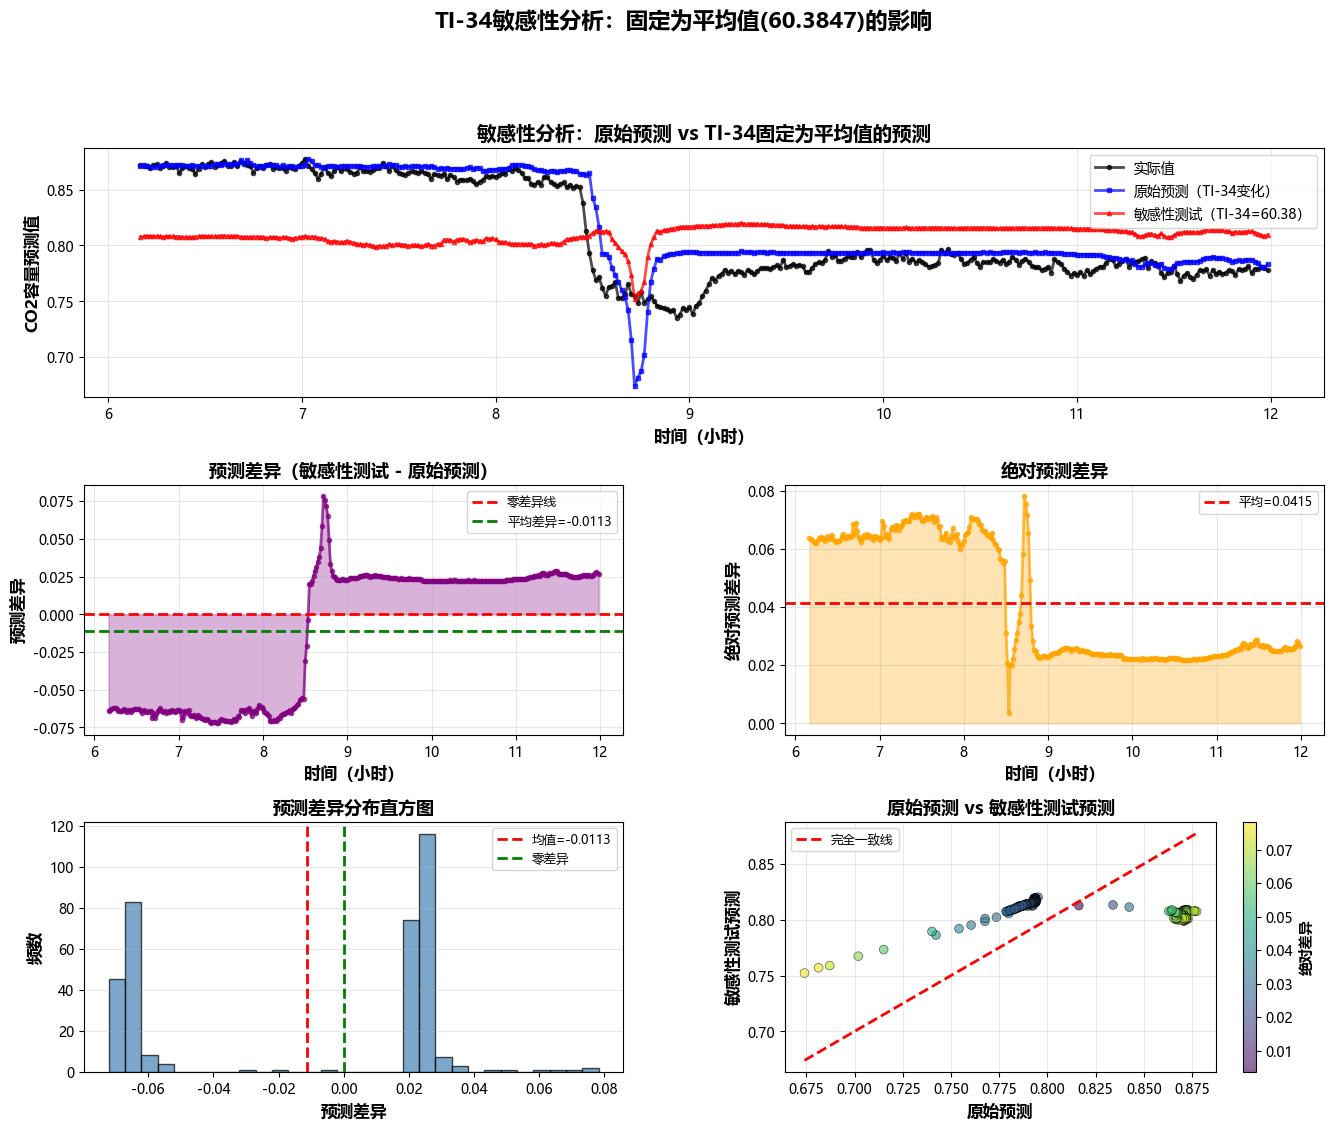

✓ 敏感性分析对比图已保存：sensitivity_analysis_TI34_comparison.png


In [25]:
# 第5步：可视化对比结果
print("\n" + "="*80)
print("绘制敏感性分析对比图")
print("="*80)

# 创建时间轴（对应滑动窗口后的时间）
time_windows = np.arange(len(y_pred_original)) / 60 + start_hour + 10/60  # 加10分钟因为窗口延迟

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# 图1：原始预测 vs 敏感性测试预测
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(time_windows, y_test_6_12_windows, 'o-', label='实际值', 
         linewidth=2, markersize=3, alpha=0.7, color='black')
ax1.plot(time_windows, y_pred_original, 's-', label='原始预测（TI-34变化）', 
         linewidth=2, markersize=3, alpha=0.7, color='blue')
ax1.plot(time_windows, y_pred_sensitivity, '^-', label=f'敏感性测试（TI-34={ti34_mean:.2f}）', 
         linewidth=2, markersize=3, alpha=0.7, color='red')
ax1.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax1.set_ylabel('CO2容量预测值', fontsize=12, fontweight='bold')
ax1.set_title('敏感性分析：原始预测 vs TI-34固定为平均值的预测', fontsize=14, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 图2：预测差异（敏感性 - 原始）
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(time_windows, pred_diff, 'o-', linewidth=2, markersize=3, alpha=0.7, color='purple')
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='零差异线')
ax2.axhline(pred_diff.mean(), color='green', linestyle='--', linewidth=2, 
            label=f'平均差异={pred_diff.mean():.4f}')
ax2.fill_between(time_windows, 0, pred_diff, alpha=0.3, color='purple')
ax2.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax2.set_ylabel('预测差异', fontsize=12, fontweight='bold')
ax2.set_title('预测差异（敏感性测试 - 原始预测）', fontsize=13, fontweight='bold')
ax2.set_xticks(range(start_hour, end_hour + 1))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图3：绝对预测差异
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(time_windows, abs_pred_diff, 'o-', linewidth=2, markersize=3, alpha=0.7, color='orange')
ax3.axhline(abs_pred_diff.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'平均={abs_pred_diff.mean():.4f}')
ax3.fill_between(time_windows, 0, abs_pred_diff, alpha=0.3, color='orange')
ax3.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax3.set_ylabel('绝对预测差异', fontsize=12, fontweight='bold')
ax3.set_title('绝对预测差异', fontsize=13, fontweight='bold')
ax3.set_xticks(range(start_hour, end_hour + 1))
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 图4：预测差异分布直方图
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(pred_diff, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax4.axvline(pred_diff.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'均值={pred_diff.mean():.4f}')
ax4.axvline(0, color='green', linestyle='--', linewidth=2, label='零差异')
ax4.set_xlabel('预测差异', fontsize=12, fontweight='bold')
ax4.set_ylabel('频数', fontsize=12, fontweight='bold')
ax4.set_title('预测差异分布直方图', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# 图5：散点图（原始预测 vs 敏感性测试预测）
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(y_pred_original, y_pred_sensitivity, alpha=0.6, s=40, c=abs_pred_diff, 
            cmap='viridis', edgecolors='black', linewidth=0.5)
min_val = min(y_pred_original.min(), y_pred_sensitivity.min())
max_val = max(y_pred_original.max(), y_pred_sensitivity.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完全一致线')
ax5.set_xlabel('原始预测', fontsize=12, fontweight='bold')
ax5.set_ylabel('敏感性测试预测', fontsize=12, fontweight='bold')
ax5.set_title('原始预测 vs 敏感性测试预测', fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)
cbar = plt.colorbar(ax5.collections[0], ax=ax5)
cbar.set_label('绝对差异', fontsize=10, fontweight='bold')

plt.suptitle(f'TI-34敏感性分析：固定为平均值({ti34_mean:.4f})的影响', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('sensitivity_analysis_TI34_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ 敏感性分析对比图已保存：sensitivity_analysis_TI34_comparison.png")

In [26]:
# 第6步：计算性能指标对比
print("\n" + "="*80)
print("性能指标对比")
print("="*80)

# 计算原始预测的性能指标
r2_original = r2_score(y_test_6_12_windows, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_original))
mae_original = mean_absolute_error(y_test_6_12_windows, y_pred_original)

# 计算敏感性测试的性能指标
r2_sensitivity = r2_score(y_test_6_12_windows, y_pred_sensitivity)
rmse_sensitivity = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_sensitivity))
mae_sensitivity = mean_absolute_error(y_test_6_12_windows, y_pred_sensitivity)

print(f"\n【原始预测性能（TI-34变化）】")
print(f"  • R²：{r2_original:.4f}")
print(f"  • RMSE：{rmse_original:.6f}")
print(f"  • MAE：{mae_original:.6f}")

print(f"\n【敏感性测试性能（TI-34={ti34_mean:.4f}）】")
print(f"  • R²：{r2_sensitivity:.4f}")
print(f"  • RMSE：{rmse_sensitivity:.6f}")
print(f"  • MAE：{mae_sensitivity:.6f}")

print(f"\n【性能变化】")
print(f"  • ΔR²：{r2_sensitivity - r2_original:.4f} ({((r2_sensitivity - r2_original) / r2_original * 100):.2f}%)")
print(f"  • ΔRMSE：{rmse_sensitivity - rmse_original:.6f} ({((rmse_sensitivity - rmse_original) / rmse_original * 100):.2f}%)")
print(f"  • ΔMAE：{mae_sensitivity - mae_original:.6f} ({((mae_sensitivity - mae_original) / mae_original * 100):.2f}%)")

print(f"\n【敏感性分析结论】")
if abs(pred_diff.mean()) < 0.001:
    print(f"  ✓ TI-34对预测影响较小（平均差异 < 0.001）")
elif abs(pred_diff.mean()) < 0.01:
    print(f"  • TI-34对预测有一定影响（平均差异 ≈ {abs(pred_diff.mean()):.4f}）")
else:
    print(f"  ⚠ TI-34对预测影响较大（平均差异 = {abs(pred_diff.mean()):.4f}）")

print(f"  • 相对影响：{relative_impact:.2f}%")
print(f"  • 模型对TI-34的敏感度：{'高' if relative_impact > 5 else '中等' if relative_impact > 1 else '低'}")


性能指标对比

【原始预测性能（TI-34变化）】
  • R²：0.8452
  • RMSE：0.017561
  • MAE：0.011295

【敏感性测试性能（TI-34=60.3847）】
  • R²：-0.1862
  • RMSE：0.048607
  • MAE：0.045725

【性能变化】
  • ΔR²：-1.0313 (-122.03%)
  • ΔRMSE：0.031046 (176.79%)
  • ΔMAE：0.034430 (304.82%)

【敏感性分析结论】
  ⚠ TI-34对预测影响较大（平均差异 = 0.0113）
  • 相对影响：5.06%
  • 模型对TI-34的敏感度：高


In [27]:
# 第7步：保存敏感性分析结果
print("\n" + "="*80)
print("保存敏感性分析结果")
print("="*80)

# 创建结果DataFrame
sensitivity_results = pd.DataFrame({
    '时间步': np.arange(len(y_pred_original)),
    '时间（小时）': time_windows,
    '实际值': y_test_6_12_windows,
    '原始预测': y_pred_original,
    '敏感性预测': y_pred_sensitivity,
    '预测差异': pred_diff,
    '绝对差异': abs_pred_diff,
    'TI-34原始值': ti34_values[10:],  # 滑动窗口减少10个样本
})

sensitivity_results.to_csv('sensitivity_TI34_results.csv', index=False, encoding='utf-8-sig')
print(f"✓ 敏感性分析结果已保存：sensitivity_TI34_results.csv")

# 创建汇总报告
sensitivity_report = f"""
{'='*80}
TI-34敏感性分析报告
{'='*80}

【分析配置】
  • 分析时间段：{start_hour}:00 - {end_hour}:00
  • 样本数量：{len(ti34_values)} 条原始数据，{len(y_pred_original)} 个预测窗口
  • 分析特征：TI-34
  • 替换策略：用平均值 {ti34_mean:.6f} 替换所有TI-34值

【TI-34统计信息】
  • 平均值：{ti34_mean:.6f}
  • 标准差：{ti34_std:.6f}
  • 最小值：{ti34_values.min():.6f}
  • 最大值：{ti34_values.max():.6f}
  • 变异系数：{(ti34_std / ti34_mean * 100):.2f}%

【预测结果对比】
  原始预测（TI-34变化）：
    • 平均值：{y_pred_original.mean():.6f}
    • 标准差：{y_pred_original.std():.6f}
    • 范围：[{y_pred_original.min():.6f}, {y_pred_original.max():.6f}]

  敏感性测试（TI-34={ti34_mean:.6f}）：
    • 平均值：{y_pred_sensitivity.mean():.6f}
    • 标准差：{y_pred_sensitivity.std():.6f}
    • 范围：[{y_pred_sensitivity.min():.6f}, {y_pred_sensitivity.max():.6f}]

【预测差异分析】
  • 平均差异：{pred_diff.mean():.6f}
  • 平均绝对差异：{abs_pred_diff.mean():.6f}
  • 差异标准差：{pred_diff.std():.6f}
  • 最大正向差异：{pred_diff.max():.6f}
  • 最大负向差异：{pred_diff.min():.6f}
  • 相对影响：{relative_impact:.2f}%

【性能指标对比】
  原始预测：
    • R²：{r2_original:.4f}
    • RMSE：{rmse_original:.6f}
    • MAE：{mae_original:.6f}

  敏感性测试：
    • R²：{r2_sensitivity:.4f}
    • RMSE：{rmse_sensitivity:.6f}
    • MAE：{mae_sensitivity:.6f}

  性能变化：
    • ΔR²：{r2_sensitivity - r2_original:.4f} ({((r2_sensitivity - r2_original) / r2_original * 100):.2f}%)
    • ΔRMSE：{rmse_sensitivity - rmse_original:.6f} ({((rmse_sensitivity - rmse_original) / rmse_original * 100):.2f}%)
    • ΔMAE：{mae_sensitivity - mae_original:.6f} ({((mae_sensitivity - mae_original) / mae_original * 100):.2f}%)

【结论】
  • TI-34敏感度：{'高' if relative_impact > 5 else '中等' if relative_impact > 1 else '低'}
  • 相对影响：{relative_impact:.2f}%
  • 说明：将TI-34固定为平均值后，模型预测值平均变化{relative_impact:.2f}%
  • 建议：{'TI-34是关键特征，需要密切监控' if relative_impact > 5 else 'TI-34对模型有一定影响' if relative_impact > 1 else 'TI-34对模型影响较小'}

{'='*80}
"""

with open('sensitivity_TI34_report.txt', 'w', encoding='utf-8') as f:
    f.write(sensitivity_report)

print(f"✓ 敏感性分析报告已保存：sensitivity_TI34_report.txt")

print("\n" + "="*80)
print("✅ TI-34敏感性分析完成！")
print("="*80)
print("\n生成的文件：")
print("  1. sensitivity_TI34_original_values.png - TI-34原始值图表")
print("  2. sensitivity_analysis_TI34_comparison.png - 敏感性分析对比图")
print("  3. sensitivity_TI34_results.csv - 详细结果数据")
print("  4. sensitivity_TI34_report.txt - 分析报告")

print(sensitivity_report)


保存敏感性分析结果
✓ 敏感性分析结果已保存：sensitivity_TI34_results.csv
✓ 敏感性分析报告已保存：sensitivity_TI34_report.txt

✅ TI-34敏感性分析完成！

生成的文件：
  1. sensitivity_TI34_original_values.png - TI-34原始值图表
  2. sensitivity_analysis_TI34_comparison.png - 敏感性分析对比图
  3. sensitivity_TI34_results.csv - 详细结果数据
  4. sensitivity_TI34_report.txt - 分析报告

TI-34敏感性分析报告

【分析配置】
  • 分析时间段：6:00 - 12:00
  • 样本数量：360 条原始数据，350 个预测窗口
  • 分析特征：TI-34
  • 替换策略：用平均值 60.384742 替换所有TI-34值

【TI-34统计信息】
  • 平均值：60.384742
  • 标准差：2.889625
  • 最小值：56.710361
  • 最大值：64.136719
  • 变异系数：4.79%

【预测结果对比】
  原始预测（TI-34变化）：
    • 平均值：0.821040
    • 标准差：0.042566
    • 范围：[0.674037, 0.877402]

  敏感性测试（TI-34=60.384742）：
    • 平均值：0.809718
    • 标准差：0.008525
    • 范围：[0.752274, 0.820208]

【预测差异分析】
  • 平均差异：-0.011322
  • 平均绝对差异：0.041508
  • 差异标准差：0.044998
  • 最大正向差异：0.078237
  • 最大负向差异：-0.072191
  • 相对影响：5.06%

【性能指标对比】
  原始预测：
    • R²：0.8452
    • RMSE：0.017561
    • MAE：0.011295

  敏感性测试：
    • R²：-0.1862
    • RMSE：0.048607
    • MAE：0.045725

  性能变化：
 

## 敏感性分析：TI-28对测试集的影响

**分析目标：**
- 分析TI-28特征对模型预测的影响
- 时间范围：测试集6点到12点（6小时 = 360分钟）
- 方法：用TI-28的平均值替换原始值，观察预测结果的变化

**分析步骤：**
1. 提取6-12点的测试集数据
2. 绘制TI-28原始值的时间序列图
3. 计算TI-28的平均值
4. 用平均值替换所有TI-28值
5. 重新构造滑动窗口并预测
6. 对比原始预测和敏感性测试预测的差异

In [28]:
# 第1步：提取TI-28数据并计算统计信息
print("="*80)
print("敏感性分析：TI-28特征对预测的影响")
print("="*80)

print(f"\n【时间范围】")
print(f"  • 分析时间段：{start_hour}:00 - {end_hour}:00")
print(f"  • 对应索引：第 {start_min} 到第 {end_min} 分钟")
print(f"  • TI-28在选定特征中的位置：索引 {selected_features.index('TI-28')}")

# 提取TI-28的值（使用已提取的6-12点数据）
ti28_values = X_test_6_12_raw['TI-28'].values
ti28_mean = ti28_values.mean()
ti28_std = ti28_values.std()

print(f"\n【TI-28统计信息（6-12点）】")
print(f"  • 样本数：{len(ti28_values)}")
print(f"  • 平均值：{ti28_mean:.6f}")
print(f"  • 标准差：{ti28_std:.6f}")
print(f"  • 最小值：{ti28_values.min():.6f}")
print(f"  • 最大值：{ti28_values.max():.6f}")

敏感性分析：TI-28特征对预测的影响

【时间范围】
  • 分析时间段：6:00 - 12:00
  • 对应索引：第 360 到第 720 分钟
  • TI-28在选定特征中的位置：索引 9

【TI-28统计信息（6-12点）】
  • 样本数：360
  • 平均值：89.986295
  • 标准差：0.547155
  • 最小值：88.415932
  • 最大值：91.900002



绘制TI-28原始值（6-12点）


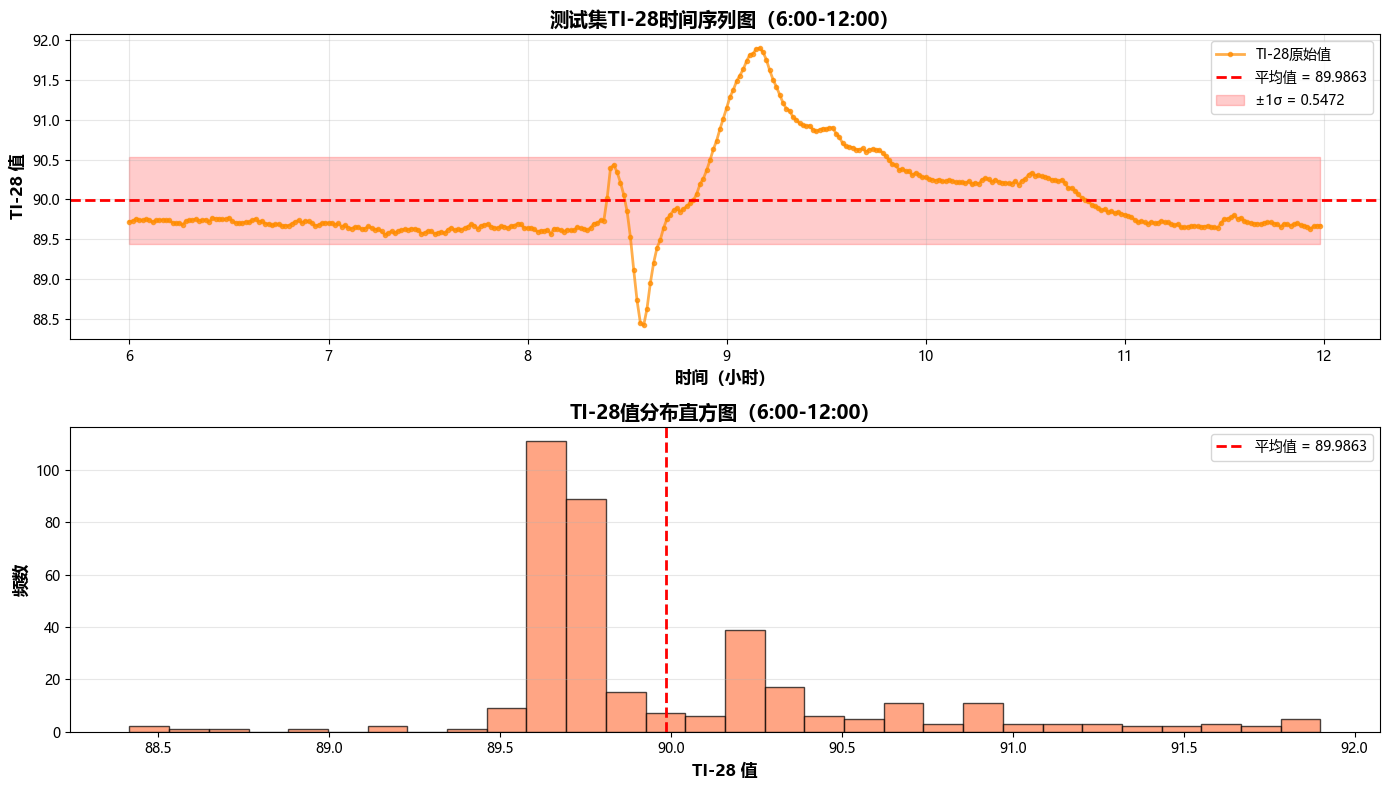

✓ TI-28原始值图表已保存：sensitivity_TI28_original_values.png


In [29]:
# 第2步：绘制TI-28原始值的时间序列图
print("\n" + "="*80)
print("绘制TI-28原始值（6-12点）")
print("="*80)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 图1：TI-28时间序列图
ax1 = axes[0]
ax1.plot(time_hours, ti28_values, 'o-', linewidth=2, markersize=3, alpha=0.7, label='TI-28原始值', color='darkorange')
ax1.axhline(ti28_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti28_mean:.4f}')
ax1.fill_between(time_hours, ti28_mean - ti28_std, ti28_mean + ti28_std, 
                  alpha=0.2, color='red', label=f'±1σ = {ti28_std:.4f}')
ax1.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax1.set_ylabel('TI-28 值', fontsize=12, fontweight='bold')
ax1.set_title('测试集TI-28时间序列图（6:00-12:00）', fontsize=14, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 图2：TI-28分布直方图
ax2 = axes[1]
ax2.hist(ti28_values, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax2.axvline(ti28_mean, color='red', linestyle='--', linewidth=2, label=f'平均值 = {ti28_mean:.4f}')
ax2.set_xlabel('TI-28 值', fontsize=12, fontweight='bold')
ax2.set_ylabel('频数', fontsize=12, fontweight='bold')
ax2.set_title('TI-28值分布直方图（6:00-12:00）', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('sensitivity_TI28_original_values.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ TI-28原始值图表已保存：sensitivity_TI28_original_values.png")

In [30]:
# 第3步：创建TI-28敏感性测试数据集（用平均值替换TI-28）
print("\n" + "="*80)
print("创建TI-28敏感性测试数据集")
print("="*80)

# 复制原始数据
X_test_6_12_sensitivity_ti28 = X_test_6_12_raw.copy()

# 用平均值替换TI-28列
X_test_6_12_sensitivity_ti28['TI-28'] = ti28_mean

print(f"\n【数据替换】")
print(f"  • 原始TI-28范围：[{ti28_values.min():.6f}, {ti28_values.max():.6f}]")
print(f"  • 替换后TI-28值：{ti28_mean:.6f}（恒定）")
print(f"  • 其他特征：保持不变")

# 验证替换
print(f"\n【验证替换结果】")
print(f"  • TI-28唯一值数量（原始）：{X_test_6_12_raw['TI-28'].nunique()}")
print(f"  • TI-28唯一值数量（替换后）：{X_test_6_12_sensitivity_ti28['TI-28'].nunique()}")
print(f"  • 替换后TI-28值：{X_test_6_12_sensitivity_ti28['TI-28'].unique()}")

# 构造滑动窗口（敏感性测试数据）
X_test_6_12_sensitivity_ti28_windows, _ = create_sliding_windows(
    X_test_6_12_sensitivity_ti28, y_test_6_12_raw, window_size=10
)

print(f"\n【滑动窗口数据】")
print(f"  • 原始窗口数：{len(X_test_6_12_windows)}")
print(f"  • TI-28敏感性测试窗口数：{len(X_test_6_12_sensitivity_ti28_windows)}")
print(f"  • 窗口特征维度：{X_test_6_12_sensitivity_ti28_windows.shape[1]}（10时间步 × {len(selected_features)}特征）")


创建TI-28敏感性测试数据集

【数据替换】
  • 原始TI-28范围：[88.415932, 91.900002]
  • 替换后TI-28值：89.986295（恒定）
  • 其他特征：保持不变

【验证替换结果】
  • TI-28唯一值数量（原始）：306
  • TI-28唯一值数量（替换后）：1
  • 替换后TI-28值：[89.9862947]

【滑动窗口数据】
  • 原始窗口数：350
  • TI-28敏感性测试窗口数：350
  • 窗口特征维度：110（10时间步 × 11特征）


In [31]:
# 第4步：使用模型进行预测（TI-28敏感性分析）
print("\n" + "="*80)
print("模型预测对比（TI-28）")
print("="*80)

# TI-28敏感性测试数据预测
y_pred_sensitivity_ti28 = rf_model.predict(X_test_6_12_sensitivity_ti28_windows)

# 计算预测差异（使用原始预测作为基准）
pred_diff_ti28 = y_pred_sensitivity_ti28 - y_pred_original
abs_pred_diff_ti28 = np.abs(pred_diff_ti28)

print(f"\n【预测结果对比】")
print(f"  • 样本数：{len(y_pred_original)}")
print(f"\n原始预测：")
print(f"  • 平均值：{y_pred_original.mean():.6f}")
print(f"  • 标准差：{y_pred_original.std():.6f}")
print(f"  • 范围：[{y_pred_original.min():.6f}, {y_pred_original.max():.6f}]")

print(f"\nTI-28敏感性测试预测（TI-28=平均值）：")
print(f"  • 平均值：{y_pred_sensitivity_ti28.mean():.6f}")
print(f"  • 标准差：{y_pred_sensitivity_ti28.std():.6f}")
print(f"  • 范围：[{y_pred_sensitivity_ti28.min():.6f}, {y_pred_sensitivity_ti28.max():.6f}]")

print(f"\n预测差异（TI-28敏感性 - 原始）：")
print(f"  • 平均差异：{pred_diff_ti28.mean():.6f}")
print(f"  • 平均绝对差异：{abs_pred_diff_ti28.mean():.6f}")
print(f"  • 差异标准差：{pred_diff_ti28.std():.6f}")
print(f"  • 最大正向差异：{pred_diff_ti28.max():.6f}")
print(f"  • 最大负向差异：{pred_diff_ti28.min():.6f}")

# 计算相对影响（百分比）
relative_impact_ti28 = (abs_pred_diff_ti28.mean() / y_pred_original.mean()) * 100
print(f"\n【TI-28敏感性指标】")
print(f"  • 相对影响：{relative_impact_ti28:.2f}%")
print(f"  • 说明：将TI-28固定为平均值后，预测值平均变化{relative_impact_ti28:.2f}%")


模型预测对比（TI-28）

【预测结果对比】
  • 样本数：350

原始预测：
  • 平均值：0.821040
  • 标准差：0.042566
  • 范围：[0.674037, 0.877402]

TI-28敏感性测试预测（TI-28=平均值）：
  • 平均值：0.824523
  • 标准差：0.037815
  • 范围：[0.792493, 0.876791]

预测差异（TI-28敏感性 - 原始）：
  • 平均差异：0.003484
  • 平均绝对差异：0.004007
  • 差异标准差：0.013583
  • 最大正向差异：0.120588
  • 最大负向差异：-0.003325

【TI-28敏感性指标】
  • 相对影响：0.49%
  • 说明：将TI-28固定为平均值后，预测值平均变化0.49%



绘制TI-28敏感性分析对比图


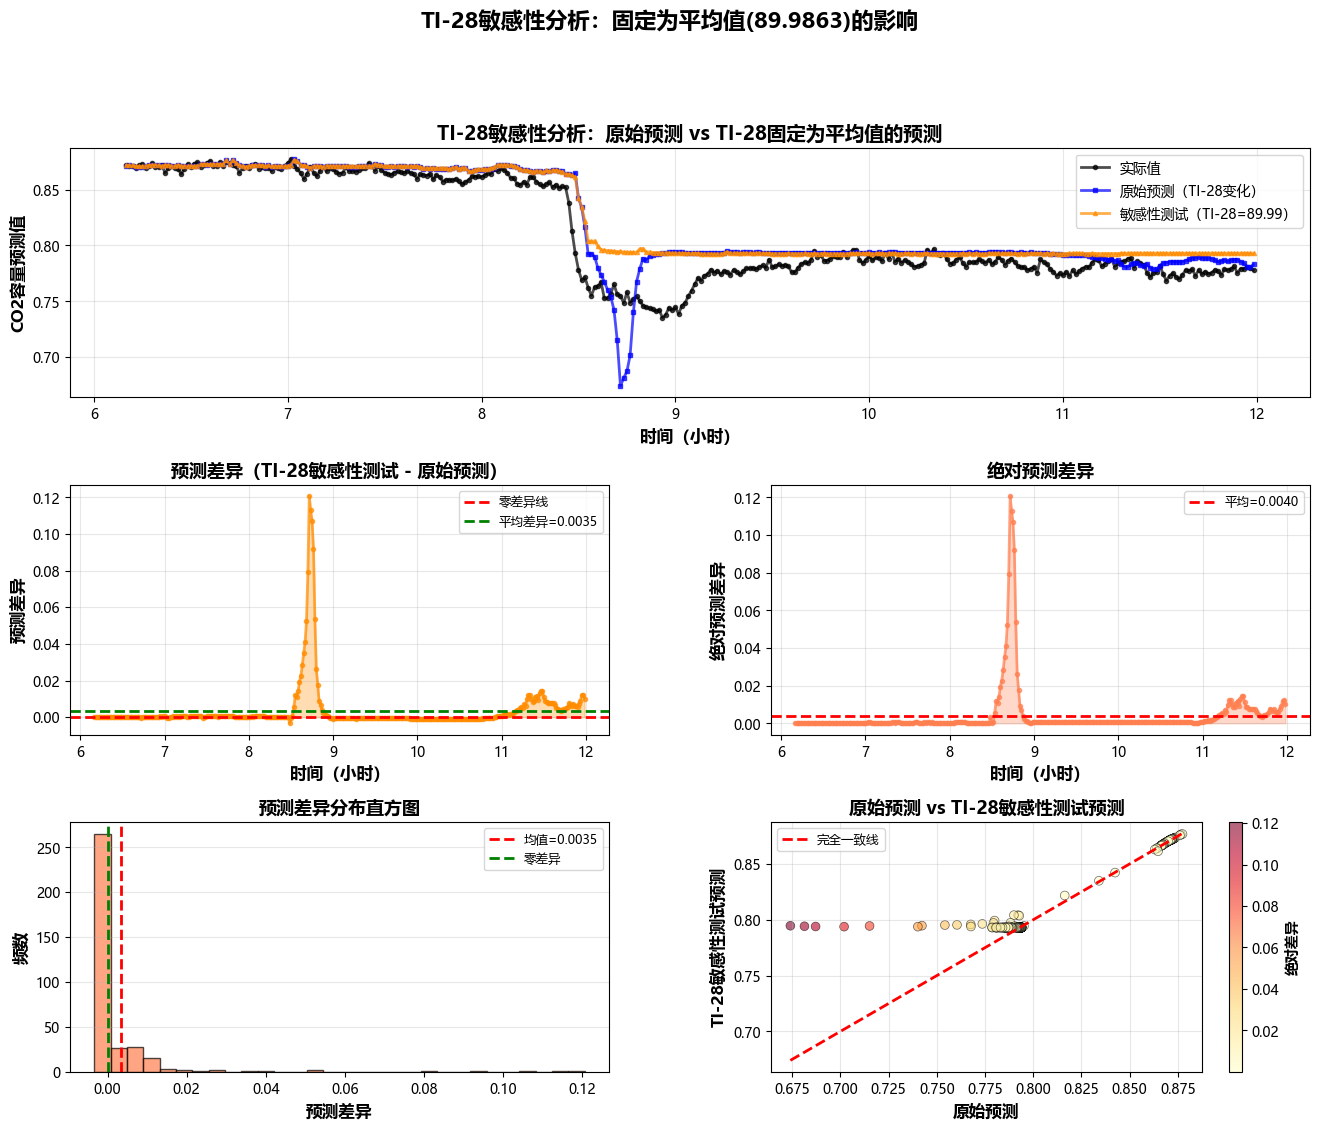

✓ TI-28敏感性分析对比图已保存：sensitivity_analysis_TI28_comparison.png


In [32]:
# 第5步：可视化TI-28敏感性分析对比结果
print("\n" + "="*80)
print("绘制TI-28敏感性分析对比图")
print("="*80)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# 图1：原始预测 vs TI-28敏感性测试预测
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(time_windows, y_test_6_12_windows, 'o-', label='实际值', 
         linewidth=2, markersize=3, alpha=0.7, color='black')
ax1.plot(time_windows, y_pred_original, 's-', label='原始预测（TI-28变化）', 
         linewidth=2, markersize=3, alpha=0.7, color='blue')
ax1.plot(time_windows, y_pred_sensitivity_ti28, '^-', label=f'敏感性测试（TI-28={ti28_mean:.2f}）', 
         linewidth=2, markersize=3, alpha=0.7, color='darkorange')
ax1.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax1.set_ylabel('CO2容量预测值', fontsize=12, fontweight='bold')
ax1.set_title('TI-28敏感性分析：原始预测 vs TI-28固定为平均值的预测', fontsize=14, fontweight='bold')
ax1.set_xticks(range(start_hour, end_hour + 1))
ax1.legend(fontsize=10, loc='best')
ax1.grid(True, alpha=0.3)

# 图2：预测差异（TI-28敏感性 - 原始）
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(time_windows, pred_diff_ti28, 'o-', linewidth=2, markersize=3, alpha=0.7, color='darkorange')
ax2.axhline(0, color='red', linestyle='--', linewidth=2, label='零差异线')
ax2.axhline(pred_diff_ti28.mean(), color='green', linestyle='--', linewidth=2, 
            label=f'平均差异={pred_diff_ti28.mean():.4f}')
ax2.fill_between(time_windows, 0, pred_diff_ti28, alpha=0.3, color='darkorange')
ax2.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax2.set_ylabel('预测差异', fontsize=12, fontweight='bold')
ax2.set_title('预测差异（TI-28敏感性测试 - 原始预测）', fontsize=13, fontweight='bold')
ax2.set_xticks(range(start_hour, end_hour + 1))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# 图3：绝对预测差异
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(time_windows, abs_pred_diff_ti28, 'o-', linewidth=2, markersize=3, alpha=0.7, color='coral')
ax3.axhline(abs_pred_diff_ti28.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'平均={abs_pred_diff_ti28.mean():.4f}')
ax3.fill_between(time_windows, 0, abs_pred_diff_ti28, alpha=0.3, color='coral')
ax3.set_xlabel('时间（小时）', fontsize=12, fontweight='bold')
ax3.set_ylabel('绝对预测差异', fontsize=12, fontweight='bold')
ax3.set_title('绝对预测差异', fontsize=13, fontweight='bold')
ax3.set_xticks(range(start_hour, end_hour + 1))
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# 图4：预测差异分布直方图
ax4 = fig.add_subplot(gs[2, 0])
ax4.hist(pred_diff_ti28, bins=30, color='coral', edgecolor='black', alpha=0.7)
ax4.axvline(pred_diff_ti28.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'均值={pred_diff_ti28.mean():.4f}')
ax4.axvline(0, color='green', linestyle='--', linewidth=2, label='零差异')
ax4.set_xlabel('预测差异', fontsize=12, fontweight='bold')
ax4.set_ylabel('频数', fontsize=12, fontweight='bold')
ax4.set_title('预测差异分布直方图', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# 图5：散点图（原始预测 vs TI-28敏感性测试预测）
ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(y_pred_original, y_pred_sensitivity_ti28, alpha=0.6, s=40, c=abs_pred_diff_ti28, 
            cmap='YlOrRd', edgecolors='black', linewidth=0.5)
min_val = min(y_pred_original.min(), y_pred_sensitivity_ti28.min())
max_val = max(y_pred_original.max(), y_pred_sensitivity_ti28.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='完全一致线')
ax5.set_xlabel('原始预测', fontsize=12, fontweight='bold')
ax5.set_ylabel('TI-28敏感性测试预测', fontsize=12, fontweight='bold')
ax5.set_title('原始预测 vs TI-28敏感性测试预测', fontsize=13, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)
cbar = plt.colorbar(ax5.collections[0], ax=ax5)
cbar.set_label('绝对差异', fontsize=10, fontweight='bold')

plt.suptitle(f'TI-28敏感性分析：固定为平均值({ti28_mean:.4f})的影响', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('sensitivity_analysis_TI28_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ TI-28敏感性分析对比图已保存：sensitivity_analysis_TI28_comparison.png")

In [33]:
# 第6步：计算TI-28性能指标对比
print("\n" + "="*80)
print("TI-28性能指标对比")
print("="*80)

# 计算TI-28敏感性测试的性能指标
r2_sensitivity_ti28 = r2_score(y_test_6_12_windows, y_pred_sensitivity_ti28)
rmse_sensitivity_ti28 = np.sqrt(mean_squared_error(y_test_6_12_windows, y_pred_sensitivity_ti28))
mae_sensitivity_ti28 = mean_absolute_error(y_test_6_12_windows, y_pred_sensitivity_ti28)

print(f"\n【原始预测性能（TI-28变化）】")
print(f"  • R²：{r2_original:.4f}")
print(f"  • RMSE：{rmse_original:.6f}")
print(f"  • MAE：{mae_original:.6f}")

print(f"\n【TI-28敏感性测试性能（TI-28={ti28_mean:.4f}）】")
print(f"  • R²：{r2_sensitivity_ti28:.4f}")
print(f"  • RMSE：{rmse_sensitivity_ti28:.6f}")
print(f"  • MAE：{mae_sensitivity_ti28:.6f}")

print(f"\n【性能变化】")
print(f"  • ΔR²：{r2_sensitivity_ti28 - r2_original:.4f} ({((r2_sensitivity_ti28 - r2_original) / r2_original * 100):.2f}%)")
print(f"  • ΔRMSE：{rmse_sensitivity_ti28 - rmse_original:.6f} ({((rmse_sensitivity_ti28 - rmse_original) / rmse_original * 100):.2f}%)")
print(f"  • ΔMAE：{mae_sensitivity_ti28 - mae_original:.6f} ({((mae_sensitivity_ti28 - mae_original) / mae_original * 100):.2f}%)")

print(f"\n【TI-28敏感性分析结论】")
if abs(pred_diff_ti28.mean()) < 0.001:
    print(f"  ✓ TI-28对预测影响较小（平均差异 < 0.001）")
elif abs(pred_diff_ti28.mean()) < 0.01:
    print(f"  • TI-28对预测有一定影响（平均差异 ≈ {abs(pred_diff_ti28.mean()):.4f}）")
else:
    print(f"  ⚠ TI-28对预测影响较大（平均差异 = {abs(pred_diff_ti28.mean()):.4f}）")

print(f"  • 相对影响：{relative_impact_ti28:.2f}%")
print(f"  • 模型对TI-28的敏感度：{'高' if relative_impact_ti28 > 5 else '中等' if relative_impact_ti28 > 1 else '低'}")


TI-28性能指标对比

【原始预测性能（TI-28变化）】
  • R²：0.8452
  • RMSE：0.017561
  • MAE：0.011295

【TI-28敏感性测试性能（TI-28=89.9863）】
  • R²：0.8288
  • RMSE：0.018465
  • MAE：0.012677

【性能变化】
  • ΔR²：-0.0164 (-1.94%)
  • ΔRMSE：0.000904 (5.15%)
  • ΔMAE：0.001382 (12.23%)

【TI-28敏感性分析结论】
  • TI-28对预测有一定影响（平均差异 ≈ 0.0035）
  • 相对影响：0.49%
  • 模型对TI-28的敏感度：低


In [34]:
# 第7步：保存TI-28敏感性分析结果
print("\n" + "="*80)
print("保存TI-28敏感性分析结果")
print("="*80)

# 创建结果DataFrame
sensitivity_results_ti28 = pd.DataFrame({
    '时间步': np.arange(len(y_pred_original)),
    '时间（小时）': time_windows,
    '实际值': y_test_6_12_windows,
    '原始预测': y_pred_original,
    'TI-28敏感性预测': y_pred_sensitivity_ti28,
    '预测差异': pred_diff_ti28,
    '绝对差异': abs_pred_diff_ti28,
    'TI-28原始值': ti28_values[10:],  # 滑动窗口减少10个样本
})

sensitivity_results_ti28.to_csv('sensitivity_TI28_results.csv', index=False, encoding='utf-8-sig')
print(f"✓ TI-28敏感性分析结果已保存：sensitivity_TI28_results.csv")

# 创建汇总报告
sensitivity_report_ti28 = f"""
{'='*80}
TI-28敏感性分析报告
{'='*80}

【分析配置】
  • 分析时间段：{start_hour}:00 - {end_hour}:00
  • 样本数量：{len(ti28_values)} 条原始数据，{len(y_pred_original)} 个预测窗口
  • 分析特征：TI-28
  • 替换策略：用平均值 {ti28_mean:.6f} 替换所有TI-28值

【TI-28统计信息】
  • 平均值：{ti28_mean:.6f}
  • 标准差：{ti28_std:.6f}
  • 最小值：{ti28_values.min():.6f}
  • 最大值：{ti28_values.max():.6f}
  • 变异系数：{(ti28_std / ti28_mean * 100):.2f}%

【预测结果对比】
  原始预测（TI-28变化）：
    • 平均值：{y_pred_original.mean():.6f}
    • 标准差：{y_pred_original.std():.6f}
    • 范围：[{y_pred_original.min():.6f}, {y_pred_original.max():.6f}]

  敏感性测试（TI-28={ti28_mean:.6f}）：
    • 平均值：{y_pred_sensitivity_ti28.mean():.6f}
    • 标准差：{y_pred_sensitivity_ti28.std():.6f}
    • 范围：[{y_pred_sensitivity_ti28.min():.6f}, {y_pred_sensitivity_ti28.max():.6f}]

【预测差异分析】
  • 平均差异：{pred_diff_ti28.mean():.6f}
  • 平均绝对差异：{abs_pred_diff_ti28.mean():.6f}
  • 差异标准差：{pred_diff_ti28.std():.6f}
  • 最大正向差异：{pred_diff_ti28.max():.6f}
  • 最大负向差异：{pred_diff_ti28.min():.6f}
  • 相对影响：{relative_impact_ti28:.2f}%

【性能指标对比】
  原始预测：
    • R²：{r2_original:.4f}
    • RMSE：{rmse_original:.6f}
    • MAE：{mae_original:.6f}

  敏感性测试：
    • R²：{r2_sensitivity_ti28:.4f}
    • RMSE：{rmse_sensitivity_ti28:.6f}
    • MAE：{mae_sensitivity_ti28:.6f}

  性能变化：
    • ΔR²：{r2_sensitivity_ti28 - r2_original:.4f} ({((r2_sensitivity_ti28 - r2_original) / r2_original * 100):.2f}%)
    • ΔRMSE：{rmse_sensitivity_ti28 - rmse_original:.6f} ({((rmse_sensitivity_ti28 - rmse_original) / rmse_original * 100):.2f}%)
    • ΔMAE：{mae_sensitivity_ti28 - mae_original:.6f} ({((mae_sensitivity_ti28 - mae_original) / mae_original * 100):.2f}%)

【结论】
  • TI-28敏感度：{'高' if relative_impact_ti28 > 5 else '中等' if relative_impact_ti28 > 1 else '低'}
  • 相对影响：{relative_impact_ti28:.2f}%
  • 说明：将TI-28固定为平均值后，模型预测值平均变化{relative_impact_ti28:.2f}%
  • 建议：{'TI-28是关键特征，需要密切监控' if relative_impact_ti28 > 5 else 'TI-28对模型有一定影响' if relative_impact_ti28 > 1 else 'TI-28对模型影响较小'}

{'='*80}
"""

with open('sensitivity_TI28_report.txt', 'w', encoding='utf-8') as f:
    f.write(sensitivity_report_ti28)

print(f"✓ TI-28敏感性分析报告已保存：sensitivity_TI28_report.txt")

print("\n" + "="*80)
print("✅ TI-28敏感性分析完成！")
print("="*80)
print("\n生成的文件：")
print("  1. sensitivity_TI28_original_values.png - TI-28原始值图表")
print("  2. sensitivity_analysis_TI28_comparison.png - TI-28敏感性分析对比图")
print("  3. sensitivity_TI28_results.csv - 详细结果数据")
print("  4. sensitivity_TI28_report.txt - 分析报告")

print(sensitivity_report_ti28)


保存TI-28敏感性分析结果
✓ TI-28敏感性分析结果已保存：sensitivity_TI28_results.csv
✓ TI-28敏感性分析报告已保存：sensitivity_TI28_report.txt

✅ TI-28敏感性分析完成！

生成的文件：
  1. sensitivity_TI28_original_values.png - TI-28原始值图表
  2. sensitivity_analysis_TI28_comparison.png - TI-28敏感性分析对比图
  3. sensitivity_TI28_results.csv - 详细结果数据
  4. sensitivity_TI28_report.txt - 分析报告

TI-28敏感性分析报告

【分析配置】
  • 分析时间段：6:00 - 12:00
  • 样本数量：360 条原始数据，350 个预测窗口
  • 分析特征：TI-28
  • 替换策略：用平均值 89.986295 替换所有TI-28值

【TI-28统计信息】
  • 平均值：89.986295
  • 标准差：0.547155
  • 最小值：88.415932
  • 最大值：91.900002
  • 变异系数：0.61%

【预测结果对比】
  原始预测（TI-28变化）：
    • 平均值：0.821040
    • 标准差：0.042566
    • 范围：[0.674037, 0.877402]

  敏感性测试（TI-28=89.986295）：
    • 平均值：0.824523
    • 标准差：0.037815
    • 范围：[0.792493, 0.876791]

【预测差异分析】
  • 平均差异：0.003484
  • 平均绝对差异：0.004007
  • 差异标准差：0.013583
  • 最大正向差异：0.120588
  • 最大负向差异：-0.003325
  • 相对影响：0.49%

【性能指标对比】
  原始预测：
    • R²：0.8452
    • RMSE：0.017561
    • MAE：0.011295

  敏感性测试：
    • R²：0.8288
    • RMSE：0.018465
    • MAE：0

In [35]:
# 对比TI-34和TI-28的敏感性分析结果
print("="*80)
print("敏感性分析对比：TI-34 vs TI-28")
print("="*80)

# 创建对比表格
comparison_df = pd.DataFrame({
    '指标': ['平均值', '标准差', '最小值', '最大值', '变异系数(%)', 
            '平均预测差异', '平均绝对差异', '差异标准差', 
            '相对影响(%)', 'R²变化', 'RMSE变化', 'MAE变化', '敏感度评级'],
    'TI-34': [
        f"{ti34_mean:.6f}",
        f"{ti34_std:.6f}",
        f"{ti34_values.min():.6f}",
        f"{ti34_values.max():.6f}",
        f"{(ti34_std / ti34_mean * 100):.2f}",
        f"{pred_diff.mean():.6f}",
        f"{abs_pred_diff.mean():.6f}",
        f"{pred_diff.std():.6f}",
        f"{relative_impact:.2f}",
        f"{r2_sensitivity - r2_original:.4f}",
        f"{rmse_sensitivity - rmse_original:.6f}",
        f"{mae_sensitivity - mae_original:.6f}",
        '高' if relative_impact > 5 else '中等' if relative_impact > 1 else '低'
    ],
    'TI-28': [
        f"{ti28_mean:.6f}",
        f"{ti28_std:.6f}",
        f"{ti28_values.min():.6f}",
        f"{ti28_values.max():.6f}",
        f"{(ti28_std / ti28_mean * 100):.2f}",
        f"{pred_diff_ti28.mean():.6f}",
        f"{abs_pred_diff_ti28.mean():.6f}",
        f"{pred_diff_ti28.std():.6f}",
        f"{relative_impact_ti28:.2f}",
        f"{r2_sensitivity_ti28 - r2_original:.4f}",
        f"{rmse_sensitivity_ti28 - rmse_original:.6f}",
        f"{mae_sensitivity_ti28 - mae_original:.6f}",
        '高' if relative_impact_ti28 > 5 else '中等' if relative_impact_ti28 > 1 else '低'
    ]
})

print("\n【敏感性分析对比表】")
print(comparison_df.to_string(index=False))

# 保存对比结果
comparison_df.to_csv('sensitivity_comparison_TI34_vs_TI28.csv', index=False, encoding='utf-8-sig')
print(f"\n✓ 对比结果已保存：sensitivity_comparison_TI34_vs_TI28.csv")

# 判断哪个特征更敏感
print(f"\n【敏感性结论】")
if relative_impact > relative_impact_ti28:
    print(f"  • TI-34对模型预测的影响更大（相对影响：{relative_impact:.2f}% > {relative_impact_ti28:.2f}%）")
    print(f"  • TI-34的平均绝对差异：{abs_pred_diff.mean():.6f}")
    print(f"  • TI-28的平均绝对差异：{abs_pred_diff_ti28.mean():.6f}")
    print(f"  • 建议：优先监控TI-34特征")
elif relative_impact_ti28 > relative_impact:
    print(f"  • TI-28对模型预测的影响更大（相对影响：{relative_impact_ti28:.2f}% > {relative_impact:.2f}%）")
    print(f"  • TI-28的平均绝对差异：{abs_pred_diff_ti28.mean():.6f}")
    print(f"  • TI-34的平均绝对差异：{abs_pred_diff.mean():.6f}")
    print(f"  • 建议：优先监控TI-28特征")
else:
    print(f"  • TI-34和TI-28对模型预测的影响相当（相对影响均为{relative_impact:.2f}%）")
    print(f"  • 建议：同等重视两个特征")

敏感性分析对比：TI-34 vs TI-28

【敏感性分析对比表】
     指标     TI-34     TI-28
    平均值 60.384742 89.986295
    标准差  2.889625  0.547155
    最小值 56.710361 88.415932
    最大值 64.136719 91.900002
变异系数(%)      4.79      0.61
 平均预测差异 -0.011322  0.003484
 平均绝对差异  0.041508  0.004007
  差异标准差  0.044998  0.013583
相对影响(%)      5.06      0.49
   R²变化   -1.0313   -0.0164
 RMSE变化  0.031046  0.000904
  MAE变化  0.034430  0.001382
  敏感度评级         高         低

✓ 对比结果已保存：sensitivity_comparison_TI34_vs_TI28.csv

【敏感性结论】
  • TI-34对模型预测的影响更大（相对影响：5.06% > 0.49%）
  • TI-34的平均绝对差异：0.041508
  • TI-28的平均绝对差异：0.004007
  • 建议：优先监控TI-34特征
